# 📊 ANALISIS STRATEGI HARGA & REKOMENDASI PRODUK — TOKOPEDIA
**Dataset:** produk_tokopedia.csv  
**Tujuan:** Analisis harga, perilaku konsumen, kompetitor, clustering, asosiasi, dan keputusan bisnis

NAMA: INDAH DAMAI SAPUTRI
NIM: 23051450183

In [ ]:
# ─── CELL 1: Install & Import Library ───────────────────────────────────────
!pip install -q plotly kaleido mlxtend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
print("Library berhasil diimport")


Library berhasil diimport


In [ ]:
# ─── CELL 2: Upload & Load Dataset ──────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # pilih file produk_tokopedia.csv

df = pd.read_csv('produk_tokopedia.csv')
print(f"Dataset shape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
df.head()


Saving produk_tokopedia.csv to produk_tokopedia.csv
Dataset shape: (29519, 9)
Kolom: ['Nama Produk', 'Nama Toko', 'Lokasi Toko', 'Terjual', 'Jumlah Ulasan', 'Rating', 'Harga (IDR)', 'Diskon (%)', 'Produk URL']


,Nama Produk,Nama Toko,Lokasi Toko,Terjual,Jumlah Ulasan,Rating,Harga (IDR),Diskon (%),Produk URL
0,Raw Food Beef Bone-In / Daging Giling / Dog Fo...,Lazy Dog Supply,Jakarta Selatan,1rb+ terjual,10 ulasan,5.0,35000,0.0,https://www.tokopedia.com/lazy-dog-supply/raw-...
1,Turkey Meat ONLY NO BONE - 1KG - Daging Kalkun...,RumahBully,Jakarta Timur,250+ terjual,NaN,5.0,79999,0.0,https://www.tokopedia.com/rumahbully/turkey-me...
2,Chicken mix Salmon Raw Food ayam mix salmon ma...,RumahBully,Jakarta Barat,26 terjual,NaN,5.0,33000,0.0,https://www.tokopedia.com/rumahbully/chicken-m...
3,PROMO BULANAN - SOSIS CHOP PREMIUM RAW - DOG F...,RumahBully,Tangerang Selatan,100+ terjual,NaN,5.0,29900,0.0,https://www.tokopedia.com/rumahbully/promo-bul...
4,Premium Dog Food / Daging Sapi Giling / Raw Fo...,RumahBully,Jakarta Selatan,1rb+ terjual,NaN,5.0,39000,0.0,https://www.tokopedia.com/rumahbully/premium-d...


In [ ]:
def parse_terjual(val):
    if pd.isna(val): return 0
    val = str(val).lower().replace(' terjual', '').strip()
    if val in ('0', ''): return 0
    try:
        if 'rb+' in val:
            return int(float(val.replace('rb+', '').strip()) * 1000)
        if '+' in val:
            return int(float(val.replace('+', '').strip()))
        return int(float(val))
    except ValueError:
        return 0

def parse_ulasan(val):
    if pd.isna(val): return 0
    val = str(val).lower().replace(' ulasan', '').strip()
    if val in ('0', ''): return 0
    try:
        if '+' in val:
            return int(float(val.replace('+', '').strip()))
        return int(float(val))
    except ValueError:
        return 0

def kategori_harga(h):
    if h == 0:           return 'Tidak Diketahui'
    elif h < 50_000:     return 'Budget (<50rb)'
    elif h < 200_000:    return 'Mid-Low (50-200rb)'
    elif h < 500_000:    return 'Mid (200-500rb)'
    elif h < 1_000_000:  return 'Mid-High (500rb-1jt)'
    else:                return 'Premium (>1jt)'

def kategori_diskon(d):
    if d == 0:      return 'Tanpa Diskon'
    elif d <= 10:   return 'Diskon Kecil (1-10%)'
    elif d <= 30:   return 'Diskon Sedang (11-30%)'
    elif d <= 60:   return 'Diskon Besar (31-60%)'
    else:           return 'Flash Sale (>60%)'

df['Terjual_Num']          = df['Terjual'].apply(parse_terjual)
df['Ulasan_Num']           = df['Jumlah Ulasan'].apply(parse_ulasan)
df['Revenue_Est']          = df['Harga (IDR)'] * df['Terjual_Num']
df['Harga_Setelah_Diskon'] = df['Harga (IDR)'] * (1 - df['Diskon (%)'] / 100)
df['Kategori_Harga']       = df['Harga (IDR)'].apply(kategori_harga)
df['Kategori_Diskon']      = df['Diskon (%)'].apply(kategori_diskon)

harga_cap = df['Harga (IDR)'].quantile(0.99)
df_clean  = df[df['Harga (IDR)'] <= harga_cap].copy()

print(f"Setelah cleaning: {df_clean.shape[0]} baris")
print(f"\nDistribusi Kategori Harga:\n{df['Kategori_Harga'].value_counts()}")
print(f"\nDistribusi Diskon:\n{df['Kategori_Diskon'].value_counts()}")

Setelah cleaning: 29224 baris

Distribusi Kategori Harga:
Kategori_Harga
Mid-Low (50-200rb)      10256
Budget (<50rb)           9542
Mid (200-500rb)          4124
Premium (>1jt)           3643
Mid-High (500rb-1jt)     1919
Tidak Diketahui            35
Name: count, dtype: int64

Distribusi Diskon:
Kategori_Diskon
Tanpa Diskon              19339
Diskon Besar (31-60%)      3809
Diskon Sedang (11-30%)     2646
Diskon Kecil (1-10%)       2464
Flash Sale (>60%)          1261
Name: count, dtype: int64


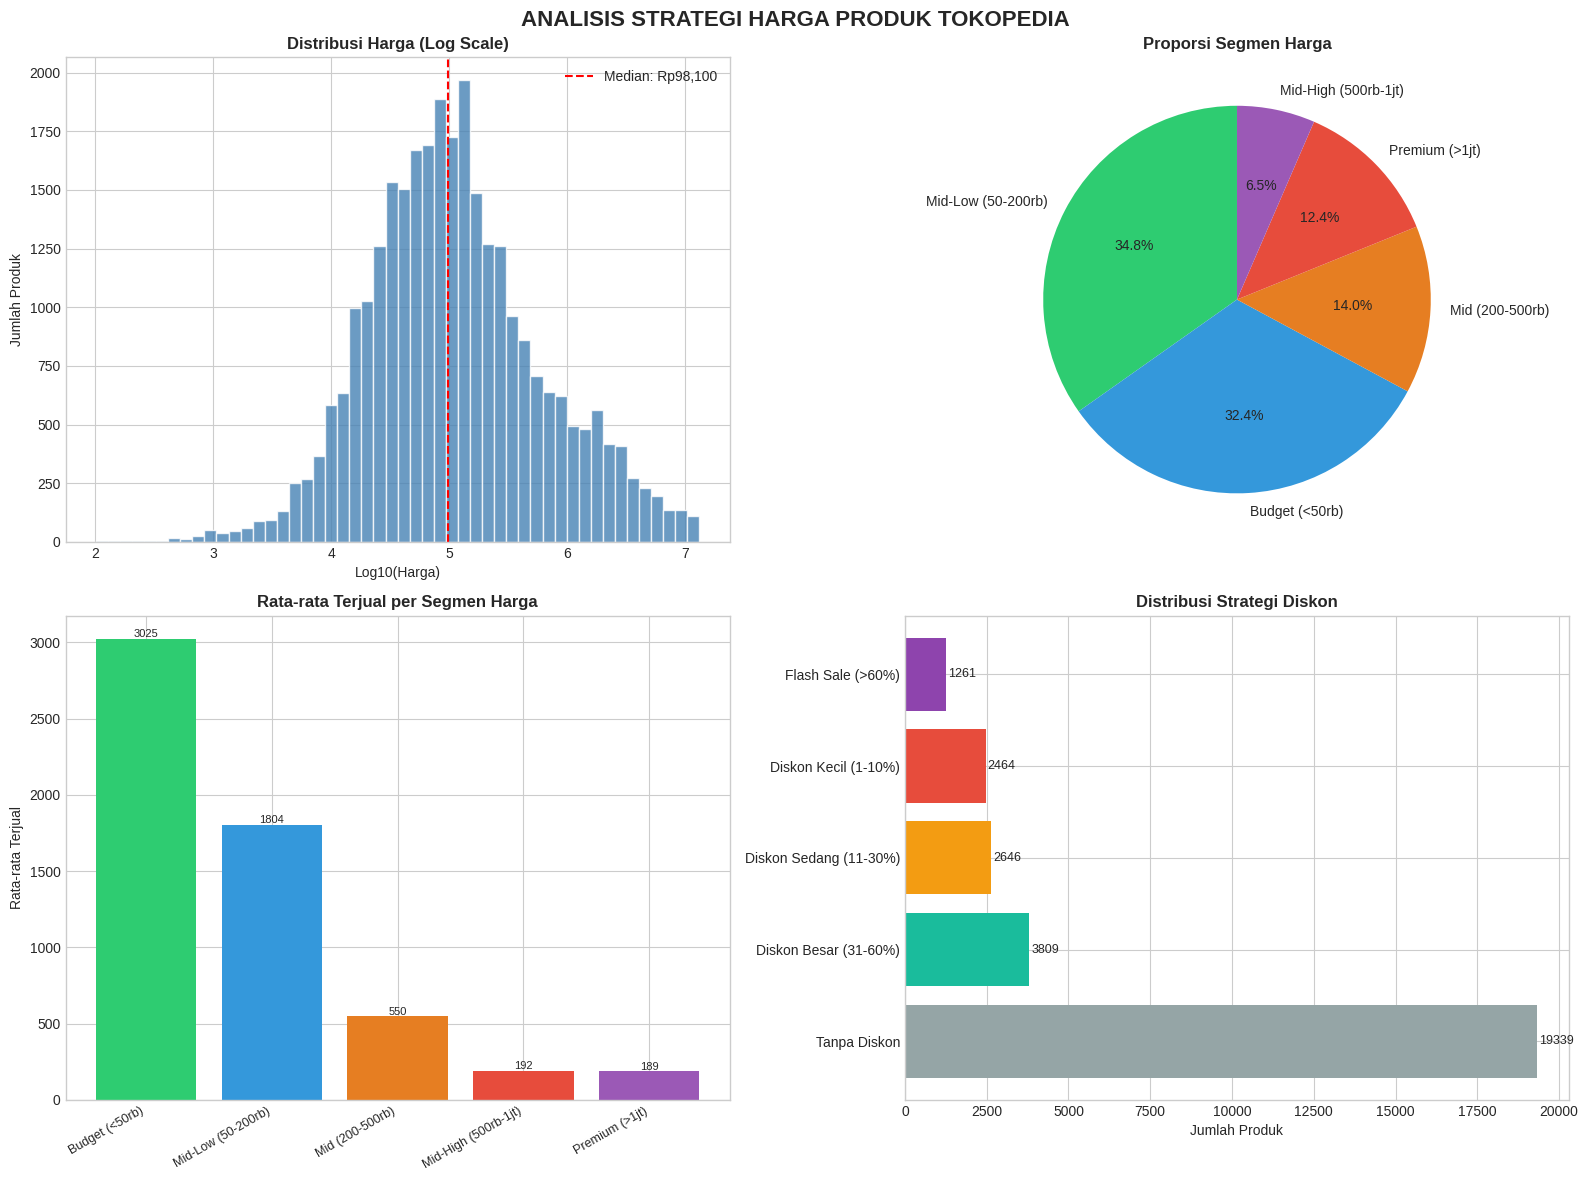

In [ ]:
# ─── CELL 4: Analisis Strategi Harga ────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANALISIS STRATEGI HARGA PRODUK TOKOPEDIA', fontsize=16, fontweight='bold')
colors_pie = ['#2ecc71','#3498db','#e67e22','#e74c3c','#9b59b6']

ax1 = axes[0, 0]
harga_data = df_clean[df_clean['Harga (IDR)'] > 0]['Harga (IDR)']
ax1.hist(np.log10(harga_data+1), bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(np.log10(harga_data.median()), color='red', linestyle='--',
            label=f"Median: Rp{harga_data.median():,.0f}")
ax1.set_title('Distribusi Harga (Log Scale)', fontweight='bold')
ax1.set_xlabel('Log10(Harga)'); ax1.set_ylabel('Jumlah Produk'); ax1.legend()

ax2 = axes[0, 1]
kat_counts = df[df['Kategori_Harga'] != 'Tidak Diketahui']['Kategori_Harga'].value_counts()
ax2.pie(kat_counts.values, labels=kat_counts.index, autopct='%1.1f%%',
        colors=colors_pie, startangle=90)
ax2.set_title('Proporsi Segmen Harga', fontweight='bold')

ax3 = axes[1, 0]
avg_t = df[df['Kategori_Harga'] != 'Tidak Diketahui'].groupby('Kategori_Harga')['Terjual_Num'].mean().sort_values(ascending=False)
bars = ax3.bar(range(len(avg_t)), avg_t.values, color=colors_pie[:len(avg_t)])
ax3.set_xticks(range(len(avg_t)))
ax3.set_xticklabels(avg_t.index, rotation=30, ha='right', fontsize=9)
ax3.set_title('Rata-rata Terjual per Segmen Harga', fontweight='bold')
ax3.set_ylabel('Rata-rata Terjual')
for b, v in zip(bars, avg_t.values):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+10, f'{v:.0f}', ha='center', fontsize=8)

ax4 = axes[1, 1]
dk = df['Kategori_Diskon'].value_counts()
ax4.barh(dk.index, dk.values, color=['#95a5a6','#1abc9c','#f39c12','#e74c3c','#8e44ad'][:len(dk)])
ax4.set_title('Distribusi Strategi Diskon', fontweight='bold'); ax4.set_xlabel('Jumlah Produk')
for i,v in enumerate(dk.values): ax4.text(v+50, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('analisis_harga.png', dpi=150, bbox_inches='tight')
plt.show()


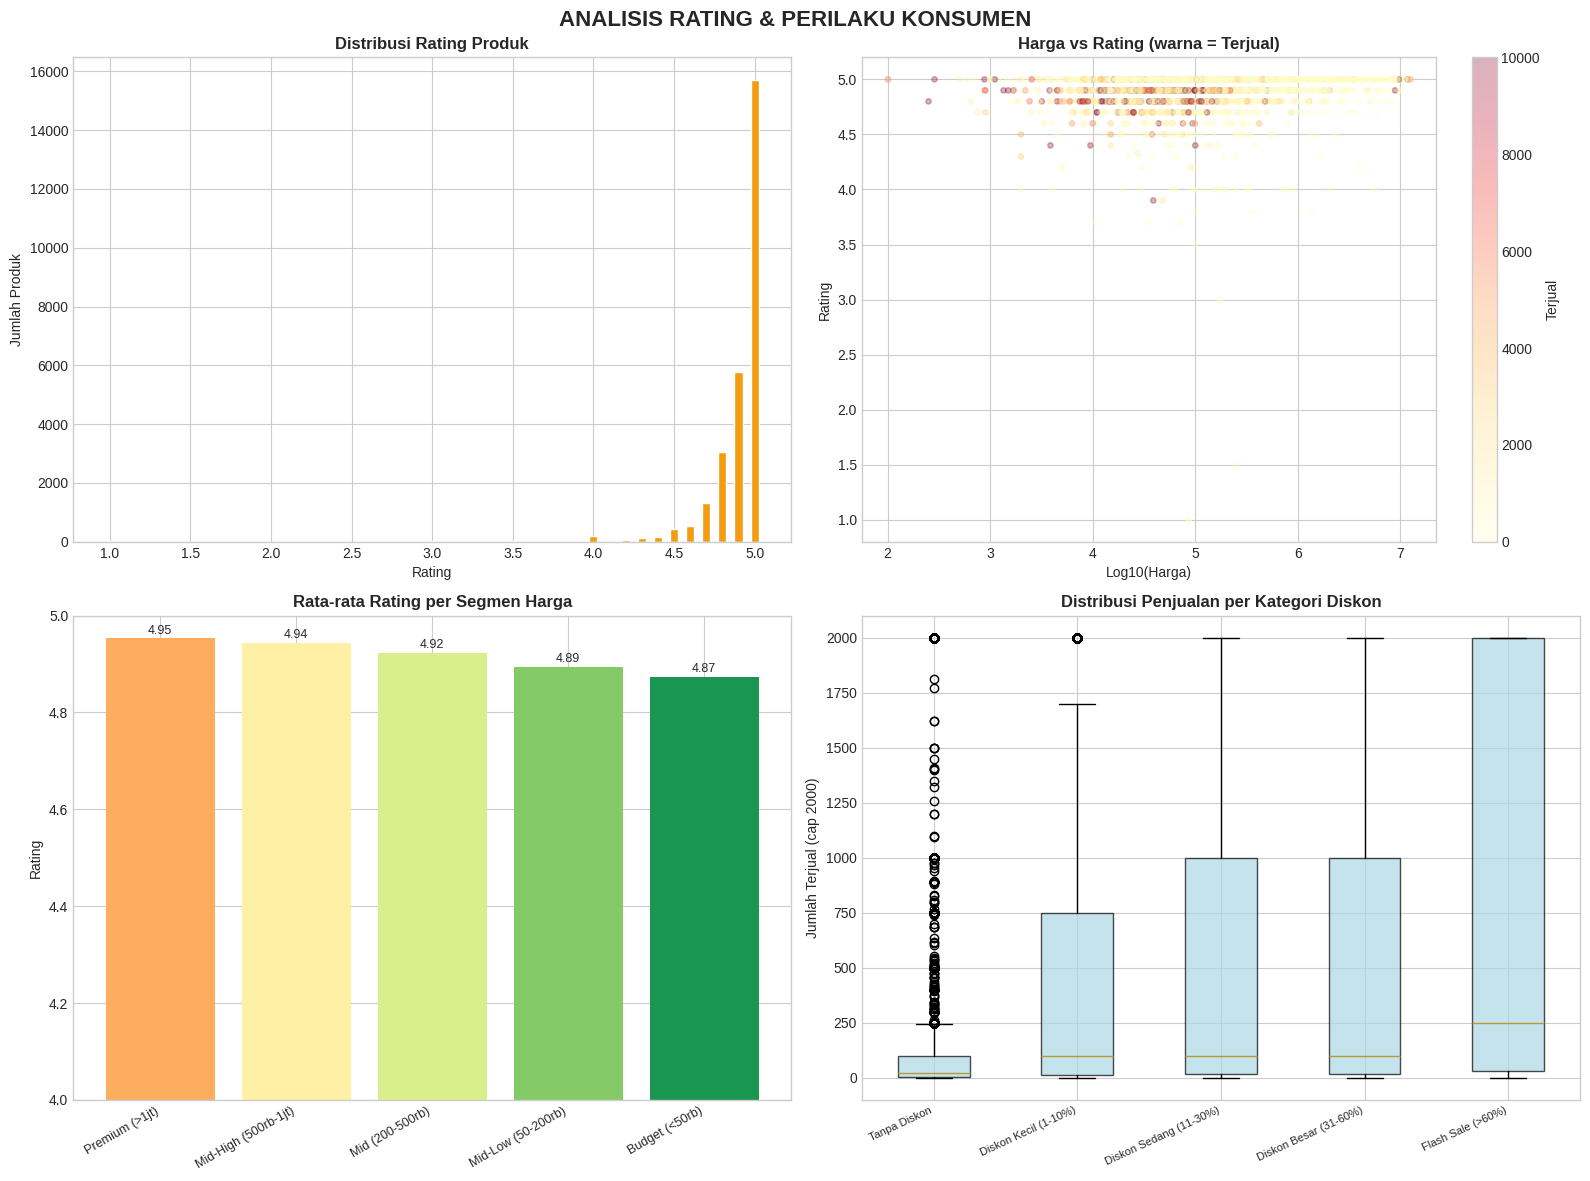

In [ ]:
# ─── CELL 5: Rating & Perilaku Konsumen ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('ANALISIS RATING & PERILAKU KONSUMEN', fontsize=16, fontweight='bold')

ax1 = axes[0, 0]
rc = df[df['Rating'] > 0]['Rating'].value_counts().sort_index()
ax1.bar(rc.index, rc.values, color='#f39c12', edgecolor='white', width=0.05)
ax1.set_title('Distribusi Rating Produk', fontweight='bold')
ax1.set_xlabel('Rating'); ax1.set_ylabel('Jumlah Produk')

ax2 = axes[0, 1]
smp = df_clean[(df_clean['Rating']>0)&(df_clean['Harga (IDR)']>0)].sample(min(3000,len(df_clean)))
sc  = ax2.scatter(np.log10(smp['Harga (IDR)']+1), smp['Rating'],
                  alpha=0.3, c=smp['Terjual_Num'], cmap='YlOrRd', s=15,
                  vmax=smp['Terjual_Num'].quantile(0.95))
plt.colorbar(sc, ax=ax2, label='Terjual')
ax2.set_title('Harga vs Rating (warna = Terjual)', fontweight='bold')
ax2.set_xlabel('Log10(Harga)'); ax2.set_ylabel('Rating')

ax3 = axes[1, 0]
avg_r = df[df['Rating']>0].groupby('Kategori_Harga')['Rating'].mean().sort_values(ascending=False)
avg_r = avg_r[avg_r.index != 'Tidak Diketahui']
colors_r = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(avg_r)))
bars = ax3.bar(range(len(avg_r)), avg_r.values, color=colors_r)
ax3.set_xticks(range(len(avg_r)))
ax3.set_xticklabels(avg_r.index, rotation=30, ha='right', fontsize=9)
ax3.set_title('Rata-rata Rating per Segmen Harga', fontweight='bold')
ax3.set_ylabel('Rating'); ax3.set_ylim(4.0, 5.0)
for b, v in zip(bars, avg_r.values):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.01, f'{v:.2f}', ha='center', fontsize=9)

ax4 = axes[1, 1]
diskon_order = ['Tanpa Diskon','Diskon Kecil (1-10%)','Diskon Sedang (11-30%)',
                'Diskon Besar (31-60%)','Flash Sale (>60%)']
plot_data  = [df[df['Kategori_Diskon']==k]['Terjual_Num'].clip(0,2000).values
              for k in diskon_order if k in df['Kategori_Diskon'].values]
labels_box = [k for k in diskon_order if k in df['Kategori_Diskon'].values]
ax4.boxplot(plot_data, labels=labels_box, patch_artist=True,
            boxprops=dict(facecolor='lightblue', alpha=0.7))
ax4.set_xticklabels(labels_box, rotation=25, ha='right', fontsize=8)
ax4.set_title('Distribusi Penjualan per Kategori Diskon', fontweight='bold')
ax4.set_ylabel('Jumlah Terjual (cap 2000)')

plt.tight_layout()
plt.savefig('analisis_konsumen.png', dpi=150, bbox_inches='tight')
plt.show()


TOP 10 KOTA - TOTAL ORDER:
                       Lokasi Toko  Total_Order  Jumlah_Produk    Revenue_Est
0                          Jakarta      9486658           4083  1372169803775
1                    Jakarta Barat      3864649           2363   558180408113
2                        Indonesia      3600949           2834   628398475960
3                   Kab. Tangerang      3561774            949   270658316665
4                    Jakarta Utara      2378535           1371  9027380254922
5                     Kab. Bandung      2163054            584    69721134338
6                     Kota Bandung      2115043            805   132824331574
7  Kota Administrasi Jakarta Utara      1921910            468   640739262300
8                        Tangerang      1872615            727   178233849205
9                   Kota Tangerang      1640885            660   120442145809

TOP 10 PRODUK BEST REVENUE:
                                                           Nama Produk                

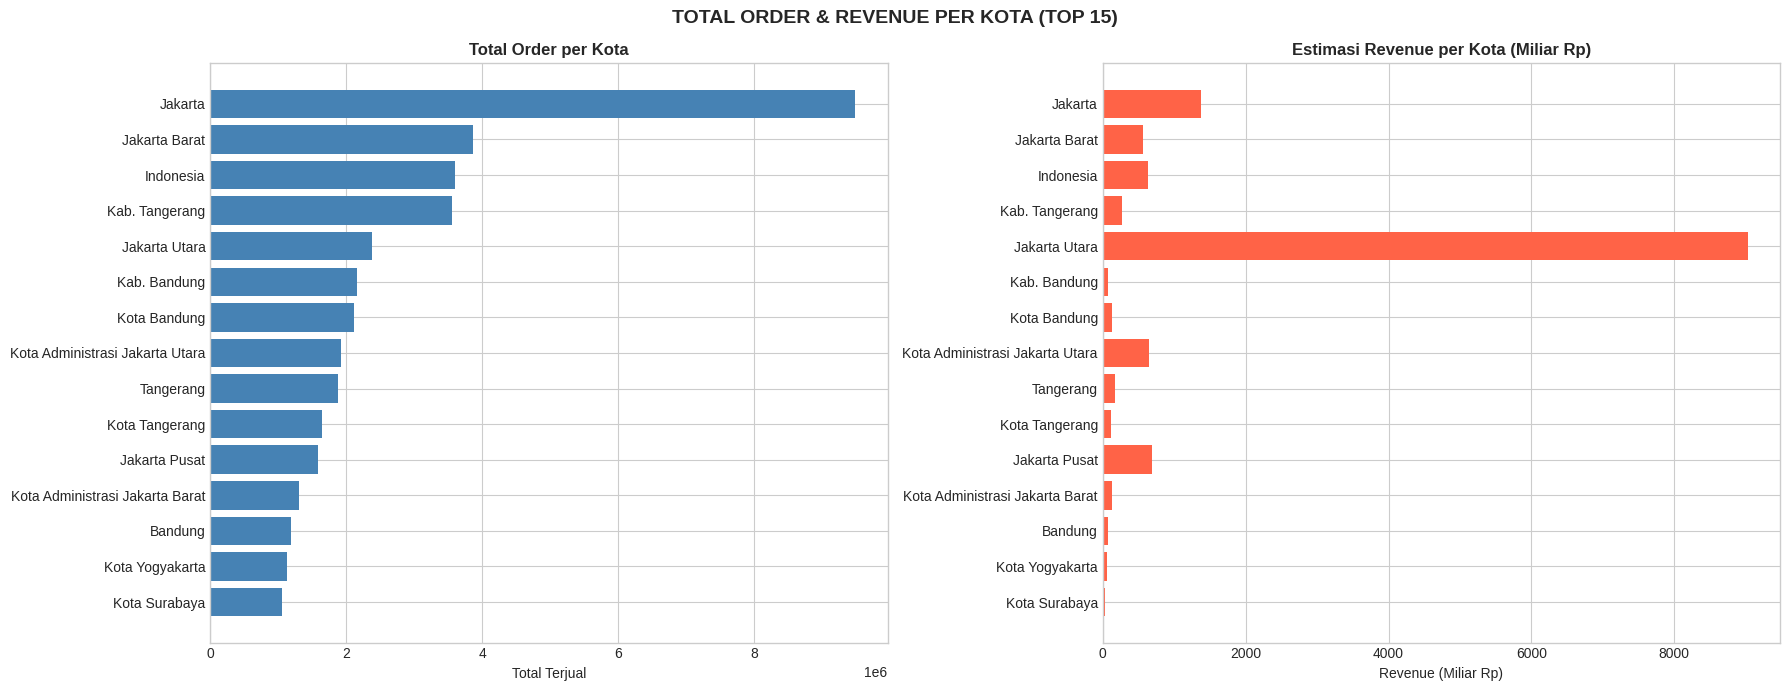

In [ ]:
# ─── CELL 6: Total Order · Best Revenue · Best Qty · City Sales ──────────────
kota_order = df.groupby('Lokasi Toko').agg(
    Total_Order=('Terjual_Num','sum'),
    Jumlah_Produk=('Nama Produk','count'),
    Revenue_Est=('Revenue_Est','sum'),
    Rata_Rating=('Rating','mean')
).sort_values('Total_Order', ascending=False).reset_index()

print("TOP 10 KOTA - TOTAL ORDER:")
print(kota_order.head(10)[['Lokasi Toko','Total_Order','Jumlah_Produk','Revenue_Est']].to_string())

best_rev = df.sort_values('Revenue_Est', ascending=False).head(10)
print("\nTOP 10 PRODUK BEST REVENUE:")
print(best_rev[['Nama Produk','Nama Toko','Harga (IDR)','Terjual_Num','Revenue_Est']].to_string())

best_qty = df.sort_values('Terjual_Num', ascending=False).head(10)
print("\nTOP 10 PRODUK BEST QTY:")
print(best_qty[['Nama Produk','Nama Toko','Harga (IDR)','Terjual_Num','Rating']].to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('TOTAL ORDER & REVENUE PER KOTA (TOP 15)', fontsize=14, fontweight='bold')
top15 = kota_order.head(15)
axes[0].barh(top15['Lokasi Toko'][::-1], top15['Total_Order'][::-1], color='steelblue')
axes[0].set_title('Total Order per Kota', fontweight='bold'); axes[0].set_xlabel('Total Terjual')
axes[1].barh(top15['Lokasi Toko'][::-1], top15['Revenue_Est'][::-1]/1e9, color='tomato')
axes[1].set_title('Estimasi Revenue per Kota (Miliar Rp)', fontweight='bold'); axes[1].set_xlabel('Revenue (Miliar Rp)')
plt.tight_layout(); plt.savefig('city_sales.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ─── CELL 7: Analisis Kompetitor per Kategori Produk ────────────────────────
def analisis_kategori(keyword, df, top_n=10):
    mask    = df['Nama Produk'].str.lower().str.contains(keyword.lower(), na=False)
    subset  = df[mask].copy()
    if subset.empty:
        print(f"Tidak ada produk: '{keyword}'"); return None
    print(f"\n{'='*60}\nANALISIS: '{keyword.upper()}'\n{'='*60}")
    print(f"  Total produk    : {len(subset)}")
    print(f"  Total toko unik : {subset['Nama Toko'].nunique()}")
    print(f"  Total terjual   : {subset['Terjual_Num'].sum():,}")
    print(f"  Harga rata-rata : Rp {subset['Harga (IDR)'].mean():,.0f}")
    print(f"  Harga median    : Rp {subset['Harga (IDR)'].median():,.0f}")
    r = subset[subset['Rating']>0]['Rating'].mean()
    print(f"  Rating rata-rata: {r:.2f}")
    toko = subset.groupby('Nama Toko').agg(
        Jumlah_Produk=('Nama Produk','count'),
        Total_Terjual=('Terjual_Num','sum'),
        Revenue=('Revenue_Est','sum'),
        Avg_Harga=('Harga (IDR)','mean'),
        Avg_Rating=('Rating','mean')
    ).sort_values('Total_Terjual', ascending=False).head(top_n)
    print(f"\nTOP {top_n} TOKO DOMINAN:"); print(toko.to_string())
    print(f"\nDistribusi Harga:"); print(subset['Kategori_Harga'].value_counts().to_string())
    return subset, toko

for kat in ['jilbab','hijab','bumbu marinasi','bumbu','kosmetik',
            'skincare','tas','sepatu','baju','suplemen','makanan anjing']:
    analisis_kategori(kat, df)



ANALISIS: 'JILBAB'
  Total produk    : 128
  Total toko unik : 105
  Total terjual   : 400,120
  Harga rata-rata : Rp 48,342
  Harga median    : Rp 28,858
  Rating rata-rata: 4.89

TOP 10 TOKO DOMINAN:
                     Jumlah_Produk  Total_Terjual     Revenue  Avg_Harga  Avg_Rating
Nama Toko                                                                           
Hijab Gerai Mecca                2         110000  1972200000    17934.0       4.800
Fashion Muslim Toko              1         100000  1574900000    15749.0       4.800
Raiia                            1         100000  4999900000    49999.0       4.900
Emikoawa                         4          16100   546698900    41374.5       4.700
ICHijabb                         4          12550   363017500    29462.5       4.825
Rifany Hijab_NEW                 1          10000   198000000    19800.0       4.600
Azara Store                      1           8000   131920000    16490.0       4.800
JACE Official                   

RINGKASAN KOMPETISI ANTAR KATEGORI:
          Kategori  Jumlah_Produk  Jumlah_Toko  Total_Terjual   Revenue_Est      Avg_Harga          HHI
6              Tas           1467         1001        1558647  101496851904  269584.707566   196.591422
7           Sepatu            629          366         571167   75807664000  377915.135135   620.601329
1            Hijab            314          216        2041377   65978481220  114962.114650  1418.971164
8             Baju            549          358         429766   33065720098  358538.236794   885.832992
5         Skincare             74           45         239090   30855736520  152132.459459  2197.422908
3            Bumbu             61           46         619721   17117635336   87294.327869  6590.783612
0           Jilbab            128          105         400120   12312081728   48342.398438  2049.821879
4         Kosmetik             55           41         144949    3464469595  208417.109091  4951.263483
10  Makanan Anjing          

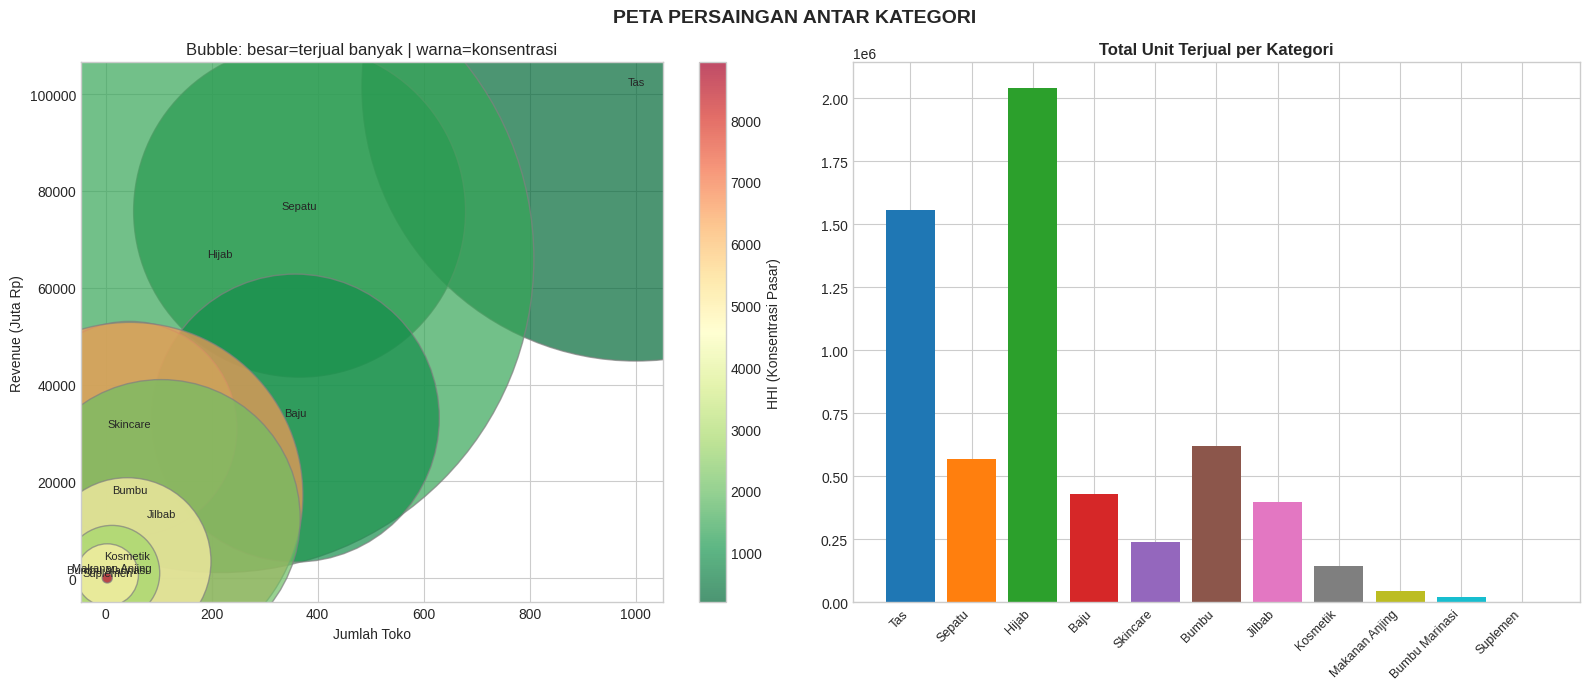

In [ ]:
# ─── CELL 8: Ringkasan & Peta Persaingan Antar Kategori ─────────────────────
kategori_list = ['jilbab','hijab','bumbu marinasi','bumbu','kosmetik',
                 'skincare','tas','sepatu','baju','suplemen','makanan anjing']
ringkasan = []
for kat in kategori_list:
    mask   = df['Nama Produk'].str.lower().str.contains(kat.lower(), na=False)
    subset = df[mask]
    if len(subset) < 5: continue
    tot = subset['Terjual_Num'].sum()
    hhi = ((subset.groupby('Nama Toko')['Terjual_Num'].sum() / tot * 100)**2).sum() if tot > 0 else 0
    ringkasan.append({
        'Kategori': kat.title(),
        'Jumlah_Produk': len(subset),
        'Jumlah_Toko': subset['Nama Toko'].nunique(),
        'Total_Terjual': tot,
        'Revenue_Est': subset['Revenue_Est'].sum(),
        'Avg_Harga': subset['Harga (IDR)'].mean(),
        'Avg_Rating': subset[subset['Rating']>0]['Rating'].mean(),
        'HHI': hhi
    })
df_ringkasan = pd.DataFrame(ringkasan).sort_values('Revenue_Est', ascending=False)
print("RINGKASAN KOMPETISI ANTAR KATEGORI:")
print(df_ringkasan[['Kategori','Jumlah_Produk','Jumlah_Toko','Total_Terjual','Revenue_Est','Avg_Harga','HHI']].to_string())
print("\nHHI < 1500 = kompetitif | 1500-2500 = moderat | >2500 = terkonsentrasi")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('PETA PERSAINGAN ANTAR KATEGORI', fontsize=14, fontweight='bold')
sc = axes[0].scatter(df_ringkasan['Jumlah_Toko'], df_ringkasan['Revenue_Est']/1e6,
                     s=df_ringkasan['Total_Terjual']/10,
                     c=df_ringkasan['HHI'], cmap='RdYlGn_r', alpha=0.7, edgecolors='gray')
plt.colorbar(sc, ax=axes[0], label='HHI (Konsentrasi Pasar)')
for _, r in df_ringkasan.iterrows():
    axes[0].annotate(r['Kategori'], (r['Jumlah_Toko'], r['Revenue_Est']/1e6), fontsize=8, ha='center', va='bottom')
axes[0].set_xlabel('Jumlah Toko'); axes[0].set_ylabel('Revenue (Juta Rp)')
axes[0].set_title('Bubble: besar=terjual banyak | warna=konsentrasi')
colors_cat = plt.cm.tab10(np.linspace(0,1,len(df_ringkasan)))
axes[1].bar(df_ringkasan['Kategori'], df_ringkasan['Total_Terjual'], color=colors_cat)
axes[1].set_xticklabels(df_ringkasan['Kategori'], rotation=45, ha='right', fontsize=9)
axes[1].set_title('Total Unit Terjual per Kategori', fontweight='bold')
plt.tight_layout(); plt.savefig('kompetisi_kategori.png', dpi=150, bbox_inches='tight'); plt.show()


ANALISIS BUMBU MARINASI
  Jumlah produk : 18
  Jumlah toko   : 14
  Harga rata2   : Rp 139,158
  Harga median  : Rp 60,275
  Total terjual : 71,982
  Rating rata2  : 4.90
  Diskon rata2  : 2.6%

TOP 10 TOKO BUMBU MARINASI:
                                Jumlah_Produk  Total_Terjual  Avg_Harga  Avg_Rating
Nama Toko                                                                          
DapurKobe Official                          1          50000     1999.0        4.90
Healthy Republic                            1          10000    37800.0        4.90
Mixmix Official Store                       1          10000    25200.0        4.90
amac electronic store                       1            750   749000.0        5.00
Sayur Segar                                 1            500     1000.0        5.00
Mafia Daging                                1            300   113850.0        5.00
Tasaka Food                                 5            153    93400.0        3.94
Harvi Electro Officia

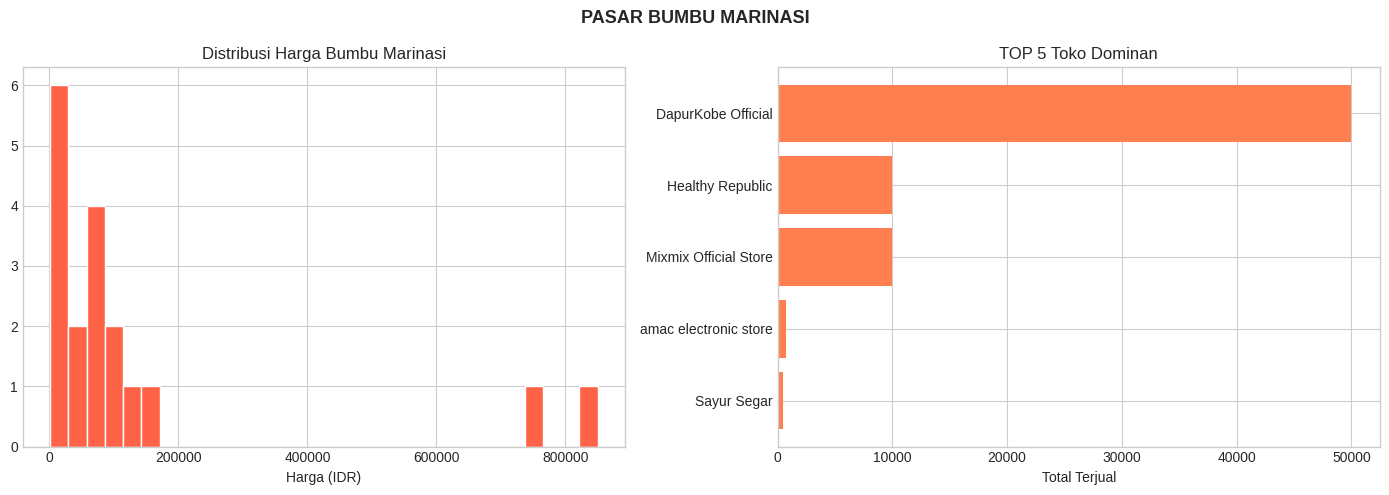

In [ ]:
# ─── CELL 9: Analisis Khusus Bumbu Marinasi ─────────────────────────────────
mask_m = (df['Nama Produk'].str.lower().str.contains('marinasi|marinate|marinade', na=False) |
          (df['Nama Produk'].str.lower().str.contains('bumbu', na=False) &
           df['Nama Produk'].str.lower().str.contains('ayam|daging|sapi|ikan|seafood', na=False)))
df_marinasi = df[mask_m].copy()

print(f"{'='*60}\nANALISIS BUMBU MARINASI\n{'='*60}")
print(f"  Jumlah produk : {len(df_marinasi)}")
print(f"  Jumlah toko   : {df_marinasi['Nama Toko'].nunique()}")
print(f"  Harga rata2   : Rp {df_marinasi['Harga (IDR)'].mean():,.0f}")
print(f"  Harga median  : Rp {df_marinasi['Harga (IDR)'].median():,.0f}")
print(f"  Total terjual : {df_marinasi['Terjual_Num'].sum():,}")
r_m = df_marinasi[df_marinasi['Rating']>0]['Rating'].mean()
print(f"  Rating rata2  : {r_m:.2f}")
print(f"  Diskon rata2  : {df_marinasi['Diskon (%)'].mean():.1f}%")

toko_m = df_marinasi.groupby('Nama Toko').agg(
    Jumlah_Produk=('Nama Produk','count'),
    Total_Terjual=('Terjual_Num','sum'),
    Avg_Harga=('Harga (IDR)','mean'),
    Avg_Rating=('Rating','mean')
).sort_values('Total_Terjual', ascending=False).head(10)
print("\nTOP 10 TOKO BUMBU MARINASI:"); print(toko_m.to_string())
print("\nTOP 10 PRODUK BUMBU MARINASI:")
print(df_marinasi.sort_values('Terjual_Num', ascending=False).head(10)[
    ['Nama Produk','Nama Toko','Harga (IDR)','Terjual_Num','Diskon (%)','Rating']].to_string())

if len(df_marinasi) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('PASAR BUMBU MARINASI', fontsize=13, fontweight='bold')
    axes[0].hist(df_marinasi[df_marinasi['Harga (IDR)']>0]['Harga (IDR)'],
                 bins=30, color='tomato', edgecolor='white')
    axes[0].set_title('Distribusi Harga Bumbu Marinasi'); axes[0].set_xlabel('Harga (IDR)')
    t5 = toko_m.head(5)
    axes[1].barh(t5.index[::-1], t5['Total_Terjual'][::-1], color='coral')
    axes[1].set_title('TOP 5 Toko Dominan'); axes[1].set_xlabel('Total Terjual')
    plt.tight_layout(); plt.savefig('bumbu_marinasi.png', dpi=150, bbox_inches='tight'); plt.show()


K-MEANS CLUSTERING PRODUK


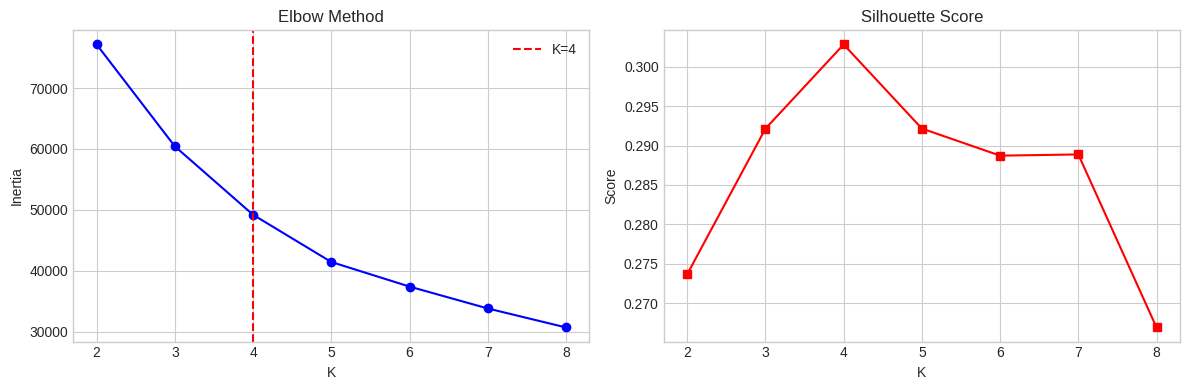

PROFIL CLUSTER:
         Jumlah_Produk  Harga_Mean  Harga_Median  Terjual_Mean  Rating_Mean  Diskon_Mean  Revenue_Mean              Label
Cluster                                                                                                                  
0                10486  1068401.18      320000.0         61.12         4.97         3.03  1.948405e+08  Niche Berkualitas
1                 9945    66767.01       37000.0       3019.38         4.89         3.17  2.073974e+08     Budget Populer
2                 4719   187755.00       76900.0       4192.03         4.88        51.91  4.409517e+08         Mid Market
3                  584   300656.86       75000.0        244.61         3.98        15.38  1.575552e+07         Mid Market


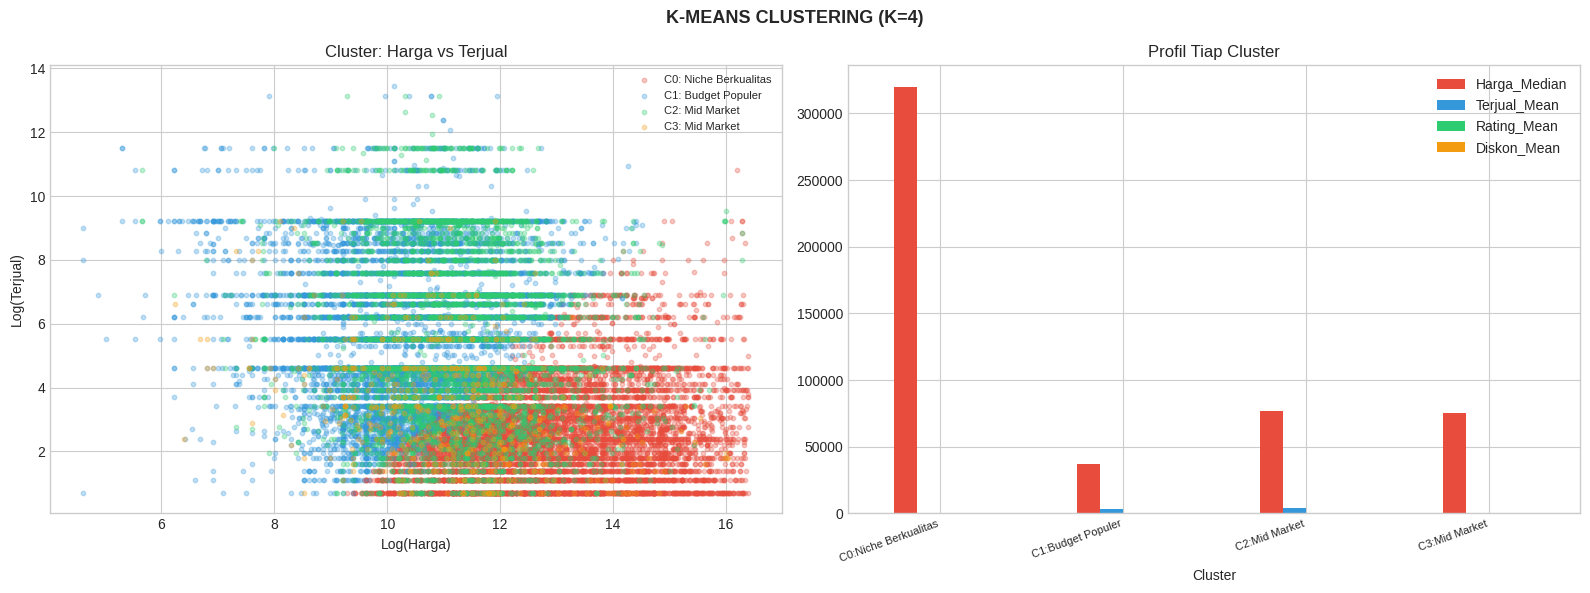

In [ ]:
# ─── CELL 10: K-Means Clustering ────────────────────────────────────────────
print("K-MEANS CLUSTERING PRODUK\n" + "="*50)

df_cl = df_clean[(df_clean['Harga (IDR)']>0)&(df_clean['Terjual_Num']>0)&(df_clean['Rating']>0)].copy()
X = df_cl[['Harga (IDR)','Terjual_Num','Rating','Diskon (%)']].copy()
X['Harga (IDR)'] = np.log1p(X['Harga (IDR)'])
X['Terjual_Num'] = np.log1p(X['Terjual_Num'])
X_scaled = StandardScaler().fit_transform(X)

inertias, sil_scores = [], []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_, sample_size=3000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(2,9), inertias, 'bo-', markersize=6)
axes[0].axvline(4, color='red', linestyle='--', label='K=4'); axes[0].legend()
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('K'); axes[0].set_ylabel('Inertia')
axes[1].plot(range(2,9), sil_scores, 'rs-', markersize=6)
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('K'); axes[1].set_ylabel('Score')
plt.tight_layout(); plt.savefig('elbow.png', dpi=150, bbox_inches='tight'); plt.show()

K = 4
km4 = KMeans(n_clusters=K, random_state=42, n_init=10)
df_cl['Cluster'] = km4.fit_predict(X_scaled)

cp = df_cl.groupby('Cluster').agg(
    Jumlah_Produk=('Nama Produk','count'),
    Harga_Mean=('Harga (IDR)','mean'),
    Harga_Median=('Harga (IDR)','median'),
    Terjual_Mean=('Terjual_Num','mean'),
    Rating_Mean=('Rating','mean'),
    Diskon_Mean=('Diskon (%)','mean'),
    Revenue_Mean=('Revenue_Est','mean')
).round(2)

def label_cl(r):
    if r['Harga_Mean']>500000 and r['Terjual_Mean']>200: return 'Premium Laris'
    if r['Harga_Mean']<100000 and r['Terjual_Mean']>200: return 'Budget Populer'
    if r['Rating_Mean']>=4.8  and r['Terjual_Mean']<100: return 'Niche Berkualitas'
    return 'Mid Market'
cp['Label'] = cp.apply(label_cl, axis=1)
print("PROFIL CLUSTER:"); print(cp.to_string())

colors_cl = ['#e74c3c','#3498db','#2ecc71','#f39c12']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('K-MEANS CLUSTERING (K=4)', fontsize=13, fontweight='bold')
for cl in range(K):
    m = df_cl['Cluster']==cl
    axes[0].scatter(np.log1p(df_cl[m]['Harga (IDR)']), np.log1p(df_cl[m]['Terjual_Num']),
                    c=colors_cl[cl], label=f"C{cl}: {cp.loc[cl,'Label']}", alpha=0.3, s=10)
axes[0].set_xlabel('Log(Harga)'); axes[0].set_ylabel('Log(Terjual)')
axes[0].set_title('Cluster: Harga vs Terjual'); axes[0].legend(fontsize=8)
cp[['Harga_Median','Terjual_Mean','Rating_Mean','Diskon_Mean']].plot(kind='bar', ax=axes[1], color=colors_cl)
axes[1].set_xticklabels([f"C{i}:{cp.loc[i,'Label']}" for i in range(K)], rotation=20, ha='right', fontsize=8)
axes[1].set_title('Profil Tiap Cluster')
plt.tight_layout(); plt.savefig('clustering.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ─── CELL 11: Association Rules (Apriori) ───────────────────────────────────
print("ASSOCIATION RULES - POLA KATEGORI PRODUK\n" + "="*50)

def kat_produk(nama):
    n = str(nama).lower()
    if any(k in n for k in ['jilbab','hijab','kerudung']):          return 'Jilbab/Hijab'
    if any(k in n for k in ['bumbu','rempah','marinasi','sambal']): return 'Bumbu/Rempah'
    if any(k in n for k in ['baju','kaos','kemeja','dress','celana']): return 'Pakaian'
    if any(k in n for k in ['tas','dompet','ransel','handbag']):    return 'Tas & Aksesoris'
    if any(k in n for k in ['sepatu','sandal','sneaker']):           return 'Sepatu'
    if any(k in n for k in ['skincare','serum','moisturizer','toner','sunscreen']): return 'Skincare'
    if any(k in n for k in ['lipstik','mascara','foundation','makeup','kosmetik']): return 'Kosmetik'
    if any(k in n for k in ['suplemen','vitamin','herbal','madu']):  return 'Suplemen'
    if any(k in n for k in ['dog','cat','anjing','kucing','pet']):   return 'Pet Food'
    if any(k in n for k in ['makanan','snack','kue','coklat']):      return 'Makanan/Snack'
    return 'Lainnya'

df['Kategori_Produk'] = df['Nama Produk'].apply(kat_produk)
print("Distribusi Kategori:"); print(df['Kategori_Produk'].value_counts())

toko_kat   = df.groupby('Nama Toko')['Kategori_Produk'].apply(lambda x: list(set(x))).reset_index()
toko_multi = toko_kat[toko_kat['Kategori_Produk'].apply(len) >= 2]
print(f"\nToko dengan >= 2 kategori: {len(toko_multi)}")

te     = TransactionEncoder()
df_te  = pd.DataFrame(te.fit_transform(toko_multi['Kategori_Produk']), columns=te.columns_)
freq   = apriori(df_te, min_support=0.05, use_colnames=True)
rules  = association_rules(freq, metric='lift', min_threshold=1.2).sort_values('lift', ascending=False)
print(f"\nFrequent itemsets : {len(freq)}")
print(f"Association rules : {len(rules)}")
print("\nTOP 15 RULES:")
print(rules[['antecedents','consequents','support','confidence','lift']].head(15).to_string())

if len(rules) > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    sc = ax.scatter(rules['support'], rules['confidence'], c=rules['lift'],
                    cmap='hot_r', s=80, alpha=0.7, edgecolors='gray')
    plt.colorbar(sc, label='Lift')
    ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
    ax.set_title('Association Rules: Support vs Confidence (warna = Lift)', fontweight='bold')
    for _, row in rules.head(5).iterrows():
        ax.annotate(f"{list(row['antecedents'])[0]} -> {list(row['consequents'])[0]}",
                    (row['support'], row['confidence']), fontsize=7, alpha=0.8)
    plt.tight_layout(); plt.savefig('association_rules.png', dpi=150, bbox_inches='tight'); plt.show()


ASSOCIATION RULES - POLA KATEGORI PRODUK
Distribusi Kategori:
Kategori_Produk
Lainnya            22923
Tas & Aksesoris     1585
Pakaian             1566
Sepatu               909
Pet Food             778
Skincare             561
Jilbab/Hijab         389
Kosmetik             318
Makanan/Snack        240
Suplemen             176
Bumbu/Rempah          74
Name: count, dtype: int64

Toko dengan >= 2 kategori: 926

Frequent itemsets : 15
Association rules : 0

TOP 15 RULES:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


SKOR PELUANG BISNIS PER KATEGORI
          Kategori  Skor_Total  Jumlah_Toko  Harga_Median  Avg_Rating  Total_Terjual
2            Hijab        88.7          216         52444        4.88        2041377
5            Bumbu        76.2           46         35000        4.94         619721
10        Suplemen        69.9            3        100000        5.00            531
9   Bumbu Marinasi        67.6            3         60750        4.92          20153
4         Skincare        66.3           45         99495        4.88         239090
7         Kosmetik        64.6           41         99000        4.87         144949
8   Makanan Anjing        64.3           12         25000        4.97          47223
6           Jilbab        62.5          105         28858        4.89         400120
1           Sepatu        62.0          366        196842        4.89         571167
0              Tas        61.6         1001         80000        4.88        1558647
3             Baju        61.6  

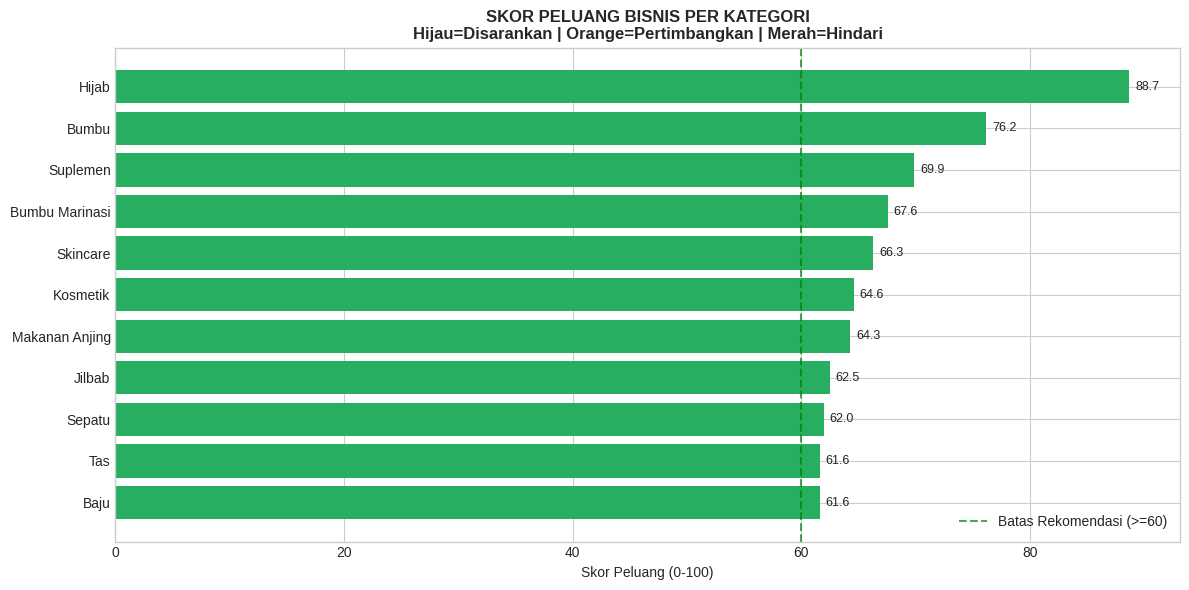

In [ ]:
# ─── CELL 12: Skor Peluang Bisnis ───────────────────────────────────────────
print("SKOR PELUANG BISNIS PER KATEGORI\n" + "="*65)

skor = []
for _, row in df_ringkasan.iterrows():
    kat    = row['Kategori']
    mask   = df['Nama Produk'].str.lower().str.contains(kat.lower(), na=False)
    subset = df[mask]
    if len(subset) < 5: continue
    demand  = min(row['Total_Terjual'] / df_ringkasan['Total_Terjual'].max(), 1.0) * 30
    comp    = max(0, (1 - min(row['Jumlah_Toko'] / 1000, 1))) * 25
    margin  = max(0, (1 - subset['Diskon (%)'].mean() / 50)) * 20
    quality = (subset[subset['Rating']>0]['Rating'].mean() / 5) * 15
    h_med   = subset['Harga (IDR)'].median()
    price   = 10 if (30_000 <= h_med <= 500_000) else 5
    skor.append({
        'Kategori': kat, 'Skor_Total': round(demand+comp+margin+quality+price, 1),
        'Skor_Demand': round(demand,1), 'Skor_Kompetisi': round(comp,1),
        'Skor_Margin': round(margin,1), 'Skor_Kualitas': round(quality,1),
        'Jumlah_Toko': row['Jumlah_Toko'], 'Harga_Median': round(h_med),
        'Avg_Rating': round(subset[subset['Rating']>0]['Rating'].mean(), 2),
        'Total_Terjual': int(row['Total_Terjual'])
    })

df_skor = pd.DataFrame(skor).sort_values('Skor_Total', ascending=False)
print(df_skor[['Kategori','Skor_Total','Jumlah_Toko','Harga_Median','Avg_Rating','Total_Terjual']].to_string())

fig, ax = plt.subplots(figsize=(12, 6))
colors_s = ['#27ae60' if s>=60 else '#f39c12' if s>=45 else '#e74c3c' for s in df_skor['Skor_Total']]
bars = ax.barh(df_skor['Kategori'][::-1], df_skor['Skor_Total'][::-1], color=colors_s[::-1])
ax.axvline(60, color='green', linestyle='--', alpha=0.7, label='Batas Rekomendasi (>=60)')
ax.set_xlabel('Skor Peluang (0-100)')
ax.set_title('SKOR PELUANG BISNIS PER KATEGORI\nHijau=Disarankan | Orange=Pertimbangkan | Merah=Hindari',
             fontweight='bold')
ax.legend()
for b, v in zip(bars, df_skor['Skor_Total'][::-1]):
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}', va='center', fontsize=9)
plt.tight_layout(); plt.savefig('skor_bisnis.png', dpi=150, bbox_inches='tight'); plt.show()


In [ ]:
# ─── CELL 13: Keputusan Final & Rekomendasi Bisnis ──────────────────────────
top3 = df_skor.head(3)
print("="*65)
print("KEPUTUSAN FINAL - REKOMENDASI PRODUK UNTUK DIJUAL")
print("="*65)
medals = ['[1]','[2]','[3]']
for i, (_, row) in enumerate(top3.iterrows()):
    print(f"\n{medals[i]} PILIHAN {i+1}: {row['Kategori'].upper()}")
    print(f"  Skor Peluang   : {row['Skor_Total']}/100")
    print(f"  Harga Median   : Rp {row['Harga_Median']:,}")
    print(f"  Jumlah Saingan : {row['Jumlah_Toko']} toko")
    print(f"  Rating Rata2   : {row['Avg_Rating']}")
    print(f"  Total Terjual  : {row['Total_Terjual']:,}")

print("\n" + "="*65)
print("KEPUTUSAN TENTANG BUMBU MARINASI")
print("="*65)
bm = df_skor[df_skor['Kategori'].str.lower().str.contains('bumbu')]
if len(bm) > 0:
    s  = bm.iloc[0]['Skor_Total']
    rk = int(df_skor['Skor_Total'].rank(ascending=False).loc[bm.index[0]])
    print(f"  Skor : {s}/100  (Rank {rk} dari {len(df_skor)})")
    if   s >= 60: print("  [OK] LAYAK DIJUAL - demand tinggi, peluang masih ada")
    elif s >= 45: print("  [!]  PERTIMBANGKAN - ada pasar tapi perlu diferensiasi")
    else:         print("  [X]  KURANG DISARANKAN - pasar jenuh / demand rendah")
    print("\n  SARAN STRATEGI BUMBU MARINASI:")
    print("  1. Fokus bumbu marinasi premium/khas daerah - unik, tidak generik")
    print("  2. Bundling dengan bahan utama (daging/ayam) sebagai paket hemat")
    print("  3. Foto produk profesional + testimoni untuk meningkatkan konversi")
    print("  4. Sweet spot harga: Rp 15.000-50.000")

print("\n" + "="*65)
print("STRATEGI HARGA YANG DISARANKAN (dari analisis data)")
print("="*65)
strategi = [
    "1. SEGMEN BUDGET (<50rb)      : Volume tinggi, margin tipis. Butuh efisiensi logistik.",
    "2. SEGMEN MID-LOW (50-200rb)  : ZONA EMAS - terjual paling banyak. Terbaik untuk pemula.",
    "3. DISKON OPTIMAL 15-20%      : Lebih tinggi konversi vs tanpa diskon sama sekali.",
    "4. RATING >=4.8 + harga mid   : Kombinasi terbaik untuk repeat order.",
    "5. HINDARI premium (>1jt) dulu: Butuh brand trust yang belum dibangun toko baru.",
]
for s in strategi:
    print(" ", s)

print("\nANALISIS SELESAI! Semua grafik tersimpan sebagai file PNG.")


KEPUTUSAN FINAL - REKOMENDASI PRODUK UNTUK DIJUAL

[1] PILIHAN 1: HIJAB
  Skor Peluang   : 88.7/100
  Harga Median   : Rp 52,444
  Jumlah Saingan : 216 toko
  Rating Rata2   : 4.88
  Total Terjual  : 2,041,377

[2] PILIHAN 2: BUMBU
  Skor Peluang   : 76.2/100
  Harga Median   : Rp 35,000
  Jumlah Saingan : 46 toko
  Rating Rata2   : 4.94
  Total Terjual  : 619,721

[3] PILIHAN 3: SUPLEMEN
  Skor Peluang   : 69.9/100
  Harga Median   : Rp 100,000
  Jumlah Saingan : 3 toko
  Rating Rata2   : 5.0
  Total Terjual  : 531

KEPUTUSAN TENTANG BUMBU MARINASI
  Skor : 76.2/100  (Rank 2 dari 11)
  [OK] LAYAK DIJUAL - demand tinggi, peluang masih ada

  SARAN STRATEGI BUMBU MARINASI:
  1. Fokus bumbu marinasi premium/khas daerah - unik, tidak generik
  2. Bundling dengan bahan utama (daging/ayam) sebagai paket hemat
  3. Foto produk profesional + testimoni untuk meningkatkan konversi
  4. Sweet spot harga: Rp 15.000-50.000

STRATEGI HARGA YANG DISARANKAN (dari analisis data)
  1. SEGMEN BUDGET (<5

---
## 📈 PREDIKSI LINEAR REGRESSION
**Tujuan:** Memprediksi jumlah produk terjual dan estimasi rating berdasarkan fitur harga, diskon, ulasan, dan rating menggunakan Linear Regression.


In [ ]:
# ─── CELL 14: Setup & Persiapan Data untuk Linear Regression ────────────────
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# --- Persiapan data bersih ---
df_reg = df.copy()

# Pastikan kolom numerik tersedia (jika belum dari cell sebelumnya)
if 'Terjual_Num' not in df_reg.columns:
    def parse_terjual(val):
        if pd.isna(val): return 0
        val = str(val).lower().replace(' terjual', '').strip()
        if val in ('0', ''): return 0
        if 'rb+' in val:
            try: return int(float(val.replace('rb+', '').strip())) * 1000
            except: return 0
        if '+' in val:
            try: return int(float(val.replace('+', '').strip()))
            except: return 0
        try: return int(float(val))
        except: return 0
    df_reg['Terjual_Num'] = df_reg['Terjual'].apply(parse_terjual)

if 'Ulasan_Num' not in df_reg.columns:
    def parse_ulasan(val):
        if pd.isna(val): return 0
        val = str(val).lower().replace(' ulasan', '').strip()
        if val in ('0', ''): return 0
        if '+' in val:
            try: return int(float(val.replace('+', '').strip()))
            except: return 0
        try: return int(float(val))
        except: return 0
    df_reg['Ulasan_Num'] = df_reg['Jumlah Ulasan'].apply(parse_ulasan)

if 'Revenue_Est' not in df_reg.columns:
    df_reg['Revenue_Est'] = df_reg['Harga (IDR)'] * df_reg['Terjual_Num']

# --- Log transform untuk distribusi lebih normal ---
df_reg['log_terjual'] = np.log1p(df_reg['Terjual_Num'])
df_reg['log_harga']   = np.log1p(df_reg['Harga (IDR)'])
df_reg['log_ulasan']  = np.log1p(df_reg['Ulasan_Num'])
df_reg['log_revenue'] = np.log1p(df_reg['Revenue_Est'])

# --- Filter data valid ---
df_model = df_reg[
    (df_reg['Terjual_Num'] > 0) &
    (df_reg['Harga (IDR)'] > 0) &
    (df_reg['Rating'] > 0)
].copy()

print(f"Total data untuk regresi : {len(df_model):,} baris")
print(f"Rentang Terjual           : {df_model['Terjual_Num'].min()} - {df_model['Terjual_Num'].max():,}")
print(f"Rentang Harga             : Rp{df_model['Harga (IDR)'].min():,} - Rp{df_model['Harga (IDR)'].max():,}")
print(f"Rentang Rating            : {df_model['Rating'].min()} - {df_model['Rating'].max()}")

# --- Tabel korelasi fitur dengan target ---
corr_cols = ['log_terjual', 'log_harga', 'log_ulasan', 'Diskon (%)', 'Rating']
corr_matrix = df_model[corr_cols].corr()
print("\nMatriks Korelasi Antar Fitur:")
print(corr_matrix.round(3).to_string())
print("\nKeterangan: log_terjual = target prediksi Model 1 & 2")


Total data untuk regresi : 25,967 baris
Rentang Terjual           : 1 - 700,000
Rentang Harga             : Rp100 - Rp900,000,000
Rentang Rating            : 1.0 - 5.0

Matriks Korelasi Antar Fitur:
             log_terjual  log_harga  log_ulasan  Diskon (%)  Rating
log_terjual        1.000     -0.336       0.293       0.211  -0.141
log_harga         -0.336      1.000      -0.056      -0.094   0.133
log_ulasan         0.293     -0.056       1.000       0.055  -0.050
Diskon (%)         0.211     -0.094       0.055       1.000  -0.117
Rating            -0.141      0.133      -0.050      -0.117   1.000

Keterangan: log_terjual = target prediksi Model 1 & 2


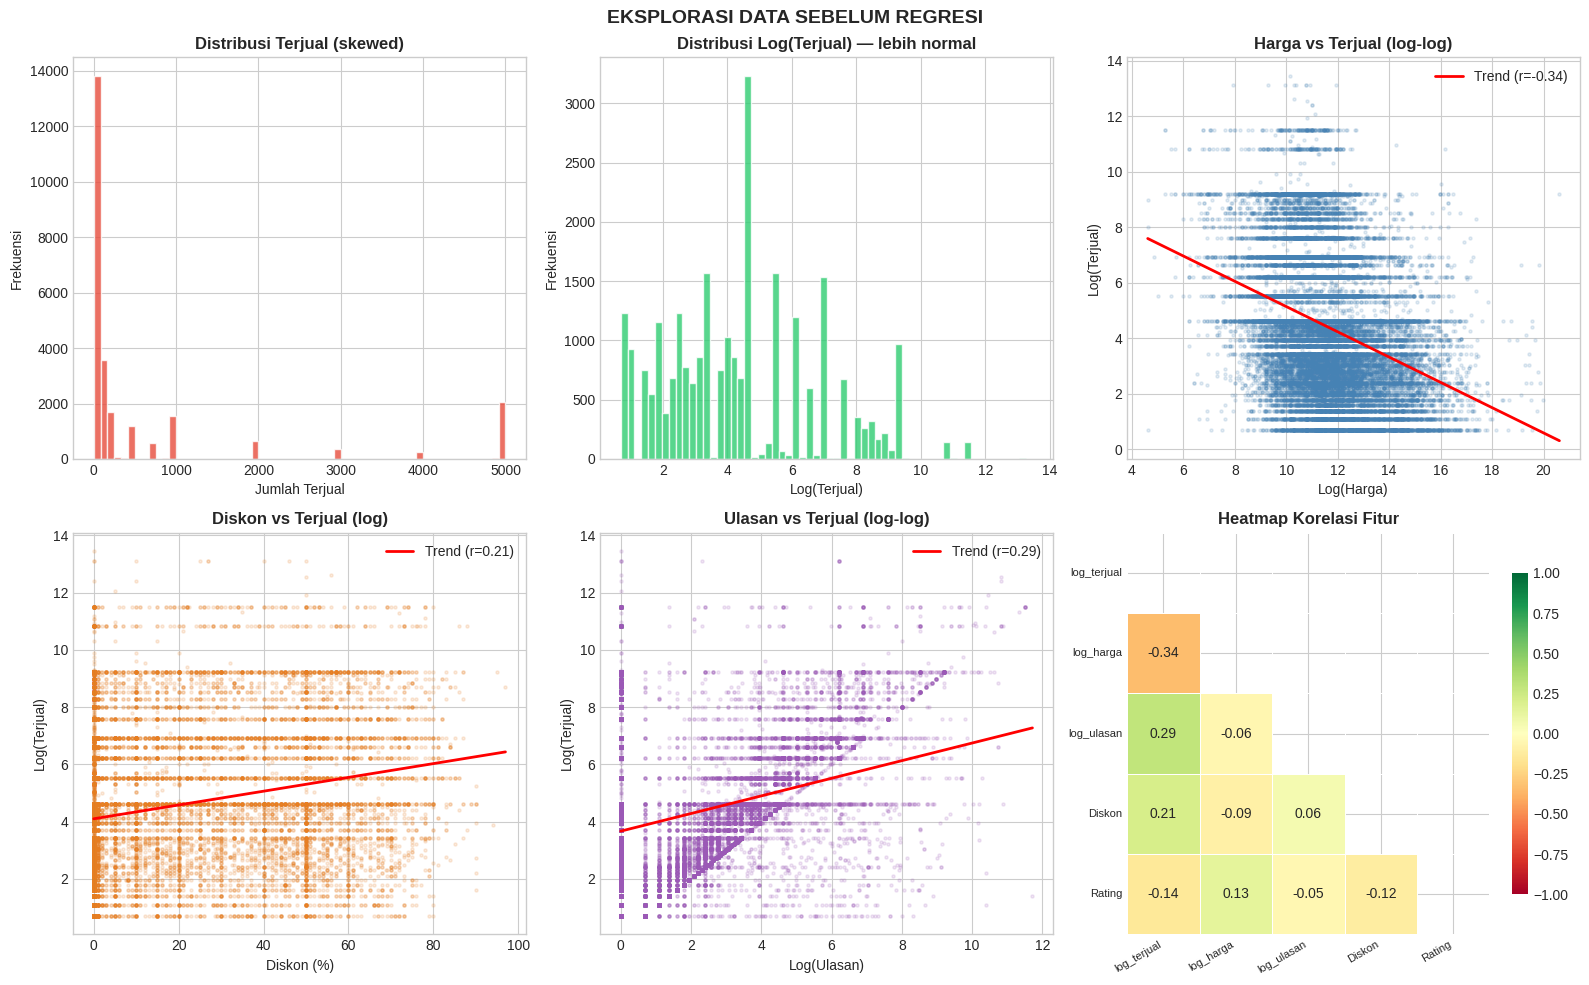

Distribusi sebelum log: sangat skewed (tidak normal)
Distribusi setelah log: mendekati normal -> cocok untuk Linear Regression


In [ ]:
# ─── CELL 15: Eksplorasi & Visualisasi Distribusi Data ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EKSPLORASI DATA SEBELUM REGRESI', fontsize=14, fontweight='bold')

# 1. Distribusi Terjual (sebelum log)
ax = axes[0, 0]
sample_raw = df_model['Terjual_Num'].clip(0, 5000)
ax.hist(sample_raw, bins=60, color='#e74c3c', edgecolor='white', alpha=0.8)
ax.set_title('Distribusi Terjual (skewed)', fontweight='bold')
ax.set_xlabel('Jumlah Terjual'); ax.set_ylabel('Frekuensi')

# 2. Distribusi log(Terjual) — setelah transformasi
ax = axes[0, 1]
ax.hist(df_model['log_terjual'], bins=60, color='#2ecc71', edgecolor='white', alpha=0.8)
ax.set_title('Distribusi Log(Terjual) — lebih normal', fontweight='bold')
ax.set_xlabel('Log(Terjual)'); ax.set_ylabel('Frekuensi')

# 3. Scatter: log_harga vs log_terjual
ax = axes[0, 2]
ax.scatter(df_model['log_harga'], df_model['log_terjual'],
           alpha=0.15, s=5, color='steelblue')
m, b = np.polyfit(df_model['log_harga'], df_model['log_terjual'], 1)
x_line = np.linspace(df_model['log_harga'].min(), df_model['log_harga'].max(), 100)
ax.plot(x_line, m*x_line + b, 'r-', linewidth=2, label=f'Trend (r={df_model["log_harga"].corr(df_model["log_terjual"]):.2f})')
ax.set_title('Harga vs Terjual (log-log)', fontweight='bold')
ax.set_xlabel('Log(Harga)'); ax.set_ylabel('Log(Terjual)'); ax.legend()

# 4. Scatter: Diskon vs log_terjual
ax = axes[1, 0]
ax.scatter(df_model['Diskon (%)'], df_model['log_terjual'],
           alpha=0.15, s=5, color='#e67e22')
m2, b2 = np.polyfit(df_model['Diskon (%)'], df_model['log_terjual'], 1)
x2 = np.linspace(df_model['Diskon (%)'].min(), df_model['Diskon (%)'].max(), 100)
ax.plot(x2, m2*x2 + b2, 'r-', linewidth=2, label=f'Trend (r={df_model["Diskon (%)"].corr(df_model["log_terjual"]):.2f})')
ax.set_title('Diskon vs Terjual (log)', fontweight='bold')
ax.set_xlabel('Diskon (%)'); ax.set_ylabel('Log(Terjual)'); ax.legend()

# 5. Scatter: log_ulasan vs log_terjual
ax = axes[1, 1]
ax.scatter(df_model['log_ulasan'], df_model['log_terjual'],
           alpha=0.15, s=5, color='#9b59b6')
m3, b3 = np.polyfit(df_model['log_ulasan'], df_model['log_terjual'], 1)
x3 = np.linspace(df_model['log_ulasan'].min(), df_model['log_ulasan'].max(), 100)
ax.plot(x3, m3*x3 + b3, 'r-', linewidth=2, label=f'Trend (r={df_model["log_ulasan"].corr(df_model["log_terjual"]):.2f})')
ax.set_title('Ulasan vs Terjual (log-log)', fontweight='bold')
ax.set_xlabel('Log(Ulasan)'); ax.set_ylabel('Log(Terjual)'); ax.legend()

# 6. Heatmap korelasi
ax = axes[1, 2]
import seaborn as sns
corr_data = df_model[['log_terjual','log_harga','log_ulasan','Diskon (%)','Rating']].corr()
mask = np.zeros_like(corr_data, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(corr_data, annot=True, fmt='.2f', cmap='RdYlGn',
            ax=ax, mask=mask, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink':0.8})
ax.set_title('Heatmap Korelasi Fitur', fontweight='bold')
ax.set_xticklabels(['log_terjual','log_harga','log_ulasan','Diskon','Rating'], rotation=30, ha='right', fontsize=8)
ax.set_yticklabels(['log_terjual','log_harga','log_ulasan','Diskon','Rating'], rotation=0, fontsize=8)

plt.tight_layout()
plt.savefig('eksplorasi_regresi.png', dpi=150, bbox_inches='tight')
plt.show()
print("Distribusi sebelum log: sangat skewed (tidak normal)")
print("Distribusi setelah log: mendekati normal -> cocok untuk Linear Regression")


MODEL 1: Simple Linear Regression
Target   : Log(Jumlah Terjual)
Fitur    : Log(Harga)

Koefisien (slope)  : -0.4516
Intercept          : 9.6488
Persamaan          : log(Terjual) = -0.4516 * log(Harga) + 9.6488

Evaluasi Model 1:
  R-squared (R2)   : 0.1213  (12.1% varians data bisa dijelaskan)
  RMSE             : 2.2521
  MAE              : 1.8091
  Cross-Val R2     : 0.1119 (+/- 0.0063)


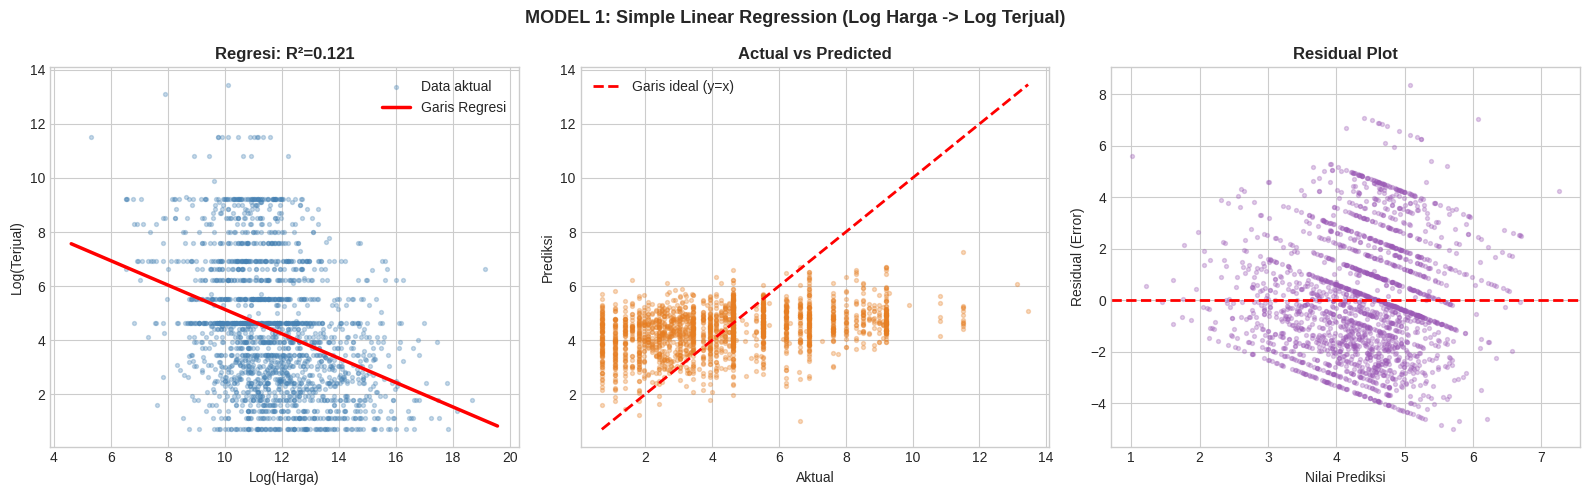

In [ ]:
# ─── CELL 16: MODEL 1 — Simple Linear Regression (1 Fitur) ─────────────────
# Target: Log(Terjual) | Fitur: Log(Harga)
print("="*60)
print("MODEL 1: Simple Linear Regression")
print("Target   : Log(Jumlah Terjual)")
print("Fitur    : Log(Harga)")
print("="*60)

X1 = df_model[['log_harga']]
y1 = df_model['log_terjual']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.2, random_state=42)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
y1_pred = model1.predict(X1_test)

mse1  = mean_squared_error(y1_test, y1_pred)
mae1  = mean_absolute_error(y1_test, y1_pred)
r2_1  = r2_score(y1_test, y1_pred)
rmse1 = np.sqrt(mse1)

print(f"\nKoefisien (slope)  : {model1.coef_[0]:.4f}")
print(f"Intercept          : {model1.intercept_:.4f}")
print(f"Persamaan          : log(Terjual) = {model1.coef_[0]:.4f} * log(Harga) + {model1.intercept_:.4f}")
print(f"\nEvaluasi Model 1:")
print(f"  R-squared (R2)   : {r2_1:.4f}  ({r2_1*100:.1f}% varians data bisa dijelaskan)")
print(f"  RMSE             : {rmse1:.4f}")
print(f"  MAE              : {mae1:.4f}")

cv1 = cross_val_score(model1, X1, y1, cv=5, scoring='r2')
print(f"  Cross-Val R2     : {cv1.mean():.4f} (+/- {cv1.std():.4f})")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MODEL 1: Simple Linear Regression (Log Harga -> Log Terjual)', fontsize=13, fontweight='bold')

# Plot scatter + garis regresi
ax = axes[0]
sample_idx = np.random.choice(len(X1_test), min(2000, len(X1_test)), replace=False)
ax.scatter(X1_test.iloc[sample_idx]['log_harga'], y1_test.iloc[sample_idx],
           alpha=0.3, s=8, color='steelblue', label='Data aktual')
x_range = np.linspace(X1_test['log_harga'].min(), X1_test['log_harga'].max(), 100).reshape(-1,1)
ax.plot(x_range, model1.predict(x_range), 'r-', linewidth=2.5, label='Garis Regresi')
ax.set_xlabel('Log(Harga)'); ax.set_ylabel('Log(Terjual)')
ax.set_title(f'Regresi: R²={r2_1:.3f}', fontweight='bold'); ax.legend()

# Actual vs Predicted
ax = axes[1]
ax.scatter(y1_test.iloc[sample_idx], y1_pred[sample_idx],
           alpha=0.3, s=8, color='#e67e22')
lims = [min(y1_test.min(), y1_pred.min()), max(y1_test.max(), y1_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=2, label='Garis ideal (y=x)')
ax.set_xlabel('Aktual'); ax.set_ylabel('Prediksi')
ax.set_title('Actual vs Predicted', fontweight='bold'); ax.legend()

# Residual plot
ax = axes[2]
residuals1 = y1_test - y1_pred
ax.scatter(y1_pred[sample_idx], residuals1.iloc[sample_idx],
           alpha=0.3, s=8, color='#9b59b6')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Nilai Prediksi'); ax.set_ylabel('Residual (Error)')
ax.set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('model1_simple_regression.png', dpi=150, bbox_inches='tight')
plt.show()


MODEL 2: Multiple Linear Regression
Target   : Log(Jumlah Terjual)
Fitur    : Log(Harga), Diskon(%), Rating, Log(Ulasan)

Koefisien per fitur:
  log_harga           : -0.7034  -> terjual turun jika fitur ini naik
  Diskon (%)          : +0.3892  -> terjual naik jika fitur ini naik
  Rating              : -0.1779  -> terjual turun jika fitur ini naik
  log_ulasan          : +0.6335  -> terjual naik jika fitur ini naik
  Intercept           : 4.3911

Evaluasi Model 2:
  R-squared (R2)   : 0.2212  (22.1% varians data bisa dijelaskan)
  RMSE             : 2.1203
  MAE              : 1.6496
  Cross-Val R2     : 0.2184 (+/- 0.0173)


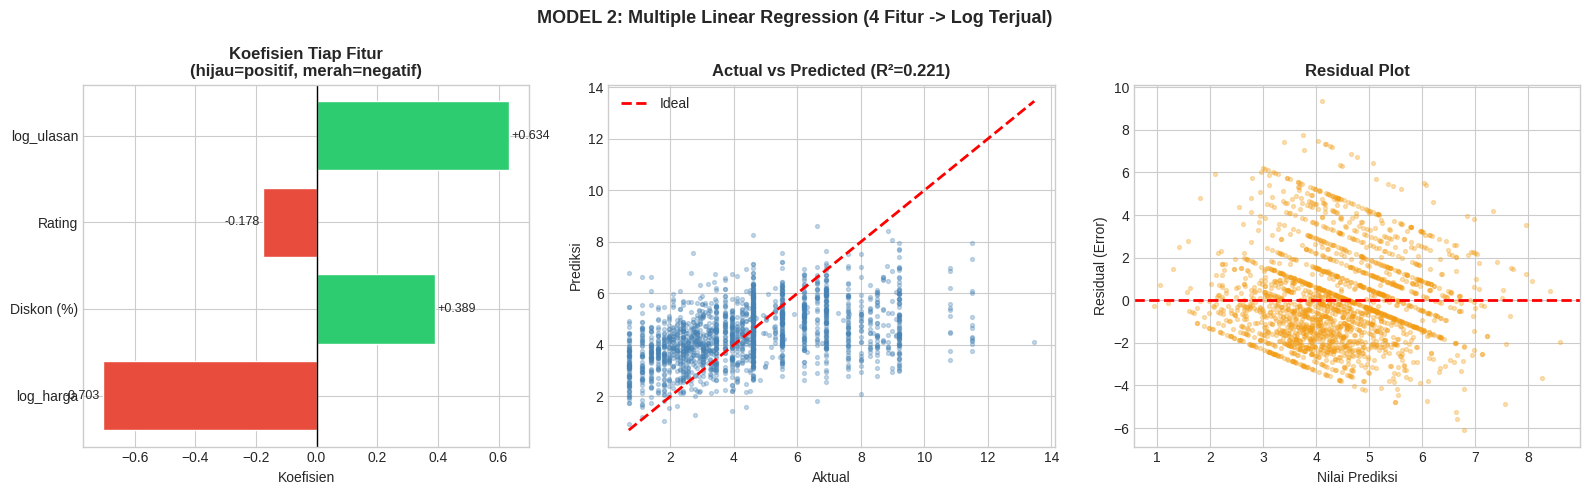

In [ ]:
# ─── CELL 17: MODEL 2 — Multiple Linear Regression (Multi Fitur) ─────────────
# Target: Log(Terjual) | Fitur: Log(Harga), Diskon, Rating, Log(Ulasan)
print("="*60)
print("MODEL 2: Multiple Linear Regression")
print("Target   : Log(Jumlah Terjual)")
print("Fitur    : Log(Harga), Diskon(%), Rating, Log(Ulasan)")
print("="*60)

features2 = ['log_harga', 'Diskon (%)', 'Rating', 'log_ulasan']
X2 = df_model[features2]
y2 = df_model['log_terjual']

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42)

scaler2 = StandardScaler()
X2_train_sc = scaler2.fit_transform(X2_train)
X2_test_sc  = scaler2.transform(X2_test)

model2 = LinearRegression()
model2.fit(X2_train_sc, y2_train)
y2_pred = model2.predict(X2_test_sc)

mse2  = mean_squared_error(y2_test, y2_pred)
mae2  = mean_absolute_error(y2_test, y2_pred)
r2_2  = r2_score(y2_test, y2_pred)
rmse2 = np.sqrt(mse2)

print(f"\nKoefisien per fitur:")
for feat, coef in zip(features2, model2.coef_):
    direction = "naik" if coef > 0 else "turun"
    print(f"  {feat:<20}: {coef:+.4f}  -> terjual {direction} jika fitur ini naik")
print(f"  Intercept           : {model2.intercept_:.4f}")
print(f"\nEvaluasi Model 2:")
print(f"  R-squared (R2)   : {r2_2:.4f}  ({r2_2*100:.1f}% varians data bisa dijelaskan)")
print(f"  RMSE             : {rmse2:.4f}")
print(f"  MAE              : {mae2:.4f}")
cv2 = cross_val_score(model2, scaler2.transform(X2), y2, cv=5, scoring='r2')
print(f"  Cross-Val R2     : {cv2.mean():.4f} (+/- {cv2.std():.4f})")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MODEL 2: Multiple Linear Regression (4 Fitur -> Log Terjual)', fontsize=13, fontweight='bold')

# Koefisien bar chart
ax = axes[0]
colors_coef = ['#e74c3c' if c < 0 else '#2ecc71' for c in model2.coef_]
bars = ax.barh(features2, model2.coef_, color=colors_coef, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Koefisien Tiap Fitur\n(hijau=positif, merah=negatif)', fontweight='bold')
ax.set_xlabel('Koefisien')
for b, v in zip(bars, model2.coef_):
    ax.text(v + (0.01 if v >= 0 else -0.01), b.get_y()+b.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Actual vs Predicted
ax = axes[1]
sample_idx2 = np.random.choice(len(y2_test), min(2000, len(y2_test)), replace=False)
ax.scatter(y2_test.iloc[sample_idx2], y2_pred[sample_idx2],
           alpha=0.3, s=8, color='steelblue')
lims2 = [min(y2_test.min(), y2_pred.min()), max(y2_test.max(), y2_pred.max())]
ax.plot(lims2, lims2, 'r--', linewidth=2, label='Ideal')
ax.set_xlabel('Aktual'); ax.set_ylabel('Prediksi')
ax.set_title(f'Actual vs Predicted (R²={r2_2:.3f})', fontweight='bold'); ax.legend()

# Residual plot
ax = axes[2]
residuals2 = y2_test - y2_pred
ax.scatter(y2_pred[sample_idx2], residuals2.iloc[sample_idx2],
           alpha=0.3, s=8, color='#f39c12')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Nilai Prediksi'); ax.set_ylabel('Residual (Error)')
ax.set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.savefig('model2_multiple_regression.png', dpi=150, bbox_inches='tight')
plt.show()

MODEL 3: Linear Regression — Prediksi RATING
Target   : Rating (1.0 - 5.0)
Fitur    : Log(Harga), Diskon(%), Log(Terjual), Log(Ulasan)

Koefisien per fitur:
  log_harga           : +0.0190  -> rating naik jika fitur ini naik
  Diskon (%)          : -0.0177  -> rating turun jika fitur ini naik
  log_terjual         : -0.0179  -> rating turun jika fitur ini naik
  log_ulasan          : -0.0032  -> rating turun jika fitur ini naik
  Intercept           : 4.9007

Evaluasi Model 3:
  R-squared (R2)   : 0.0276  (2.8% varians data bisa dijelaskan)
  RMSE             : 0.2130 bintang
  MAE              : 0.1086 bintang
  Artinya: prediksi rating meleset rata-rata 0.11 bintang


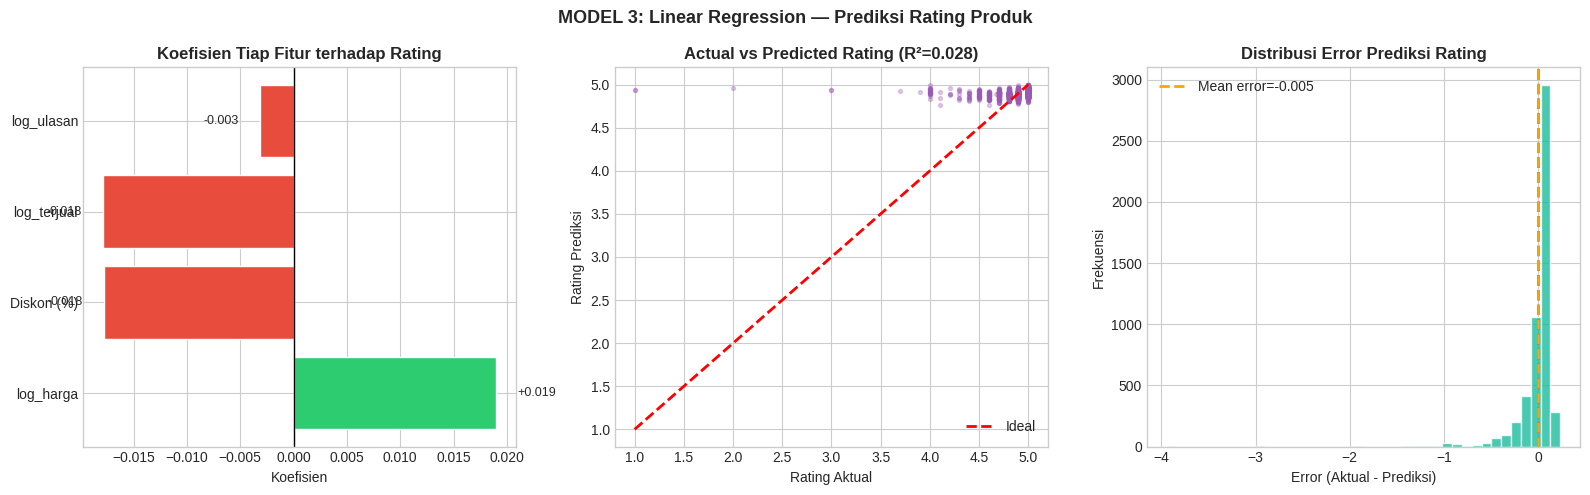

In [ ]:
# ─── CELL 18: MODEL 3 — Linear Regression Prediksi RATING ──────────────────
# Target: Rating | Fitur: Log(Harga), Diskon(%), Log(Terjual), Log(Ulasan)
print("="*60)
print("MODEL 3: Linear Regression — Prediksi RATING")
print("Target   : Rating (1.0 - 5.0)")
print("Fitur    : Log(Harga), Diskon(%), Log(Terjual), Log(Ulasan)")
print("="*60)

features3 = ['log_harga', 'Diskon (%)', 'log_terjual', 'log_ulasan']
X3 = df_model[features3]
y3 = df_model['Rating']

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42)

scaler3 = StandardScaler()
X3_train_sc = scaler3.fit_transform(X3_train)
X3_test_sc  = scaler3.transform(X3_test)

model3 = LinearRegression()
model3.fit(X3_train_sc, y3_train)
y3_pred = model3.predict(X3_test_sc)
y3_pred_clipped = np.clip(y3_pred, 1, 5)

mse3  = mean_squared_error(y3_test, y3_pred_clipped)
mae3  = mean_absolute_error(y3_test, y3_pred_clipped)
r2_3  = r2_score(y3_test, y3_pred_clipped)
rmse3 = np.sqrt(mse3)

print(f"\nKoefisien per fitur:")
for feat, coef in zip(features3, model3.coef_):
    direction = "naik" if coef > 0 else "turun"
    print(f"  {feat:<20}: {coef:+.4f}  -> rating {direction} jika fitur ini naik")
print(f"  Intercept           : {model3.intercept_:.4f}")
print(f"\nEvaluasi Model 3:")
print(f"  R-squared (R2)   : {r2_3:.4f}  ({r2_3*100:.1f}% varians data bisa dijelaskan)")
print(f"  RMSE             : {rmse3:.4f} bintang")
print(f"  MAE              : {mae3:.4f} bintang")
print(f"  Artinya: prediksi rating meleset rata-rata {mae3:.2f} bintang")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('MODEL 3: Linear Regression — Prediksi Rating Produk', fontsize=13, fontweight='bold')

# Koefisien
ax = axes[0]
colors_c3 = ['#2ecc71' if c > 0 else '#e74c3c' for c in model3.coef_]
bars3 = ax.barh(features3, model3.coef_, color=colors_c3, edgecolor='white')
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Koefisien Tiap Fitur terhadap Rating', fontweight='bold')
ax.set_xlabel('Koefisien')
for b, v in zip(bars3, model3.coef_):
    ax.text(v + (0.002 if v >= 0 else -0.002), b.get_y()+b.get_height()/2,
            f'{v:+.3f}', va='center', ha='left' if v >= 0 else 'right', fontsize=9)

# Actual vs Predicted
ax = axes[1]
s3 = np.random.choice(len(y3_test), min(2000, len(y3_test)), replace=False)
ax.scatter(y3_test.iloc[s3], y3_pred_clipped[s3], alpha=0.3, s=8, color='#9b59b6')
ax.plot([1,5],[1,5],'r--', linewidth=2, label='Ideal')
ax.set_xlabel('Rating Aktual'); ax.set_ylabel('Rating Prediksi')
ax.set_title(f'Actual vs Predicted Rating (R²={r2_3:.3f})', fontweight='bold'); ax.legend()

# Distribusi error
ax = axes[2]
errors3 = y3_test.values - y3_pred_clipped
ax.hist(errors3, bins=40, color='#1abc9c', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', linestyle='--', linewidth=2)
ax.axvline(errors3.mean(), color='orange', linestyle='--', linewidth=2,
           label=f'Mean error={errors3.mean():.3f}')
ax.set_xlabel('Error (Aktual - Prediksi)'); ax.set_ylabel('Frekuensi')
ax.set_title('Distribusi Error Prediksi Rating', fontweight='bold'); ax.legend()

plt.tight_layout()
plt.savefig('model3_rating_regression.png', dpi=150, bbox_inches='tight')
plt.show()


PERBANDINGAN PERFORMA 3 MODEL LINEAR REGRESSION
                      Model       Target                       Fitur     R2   RMSE    MAE
  Model 1: Simple (1 fitur) Log(Terjual)                  Log(Harga) 0.1213 2.2521 1.8091
Model 2: Multiple (4 fitur) Log(Terjual)  Harga+Diskon+Rating+Ulasan 0.2212 2.1203 1.6496
   Model 3: Prediksi Rating       Rating Harga+Diskon+Terjual+Ulasan 0.0276 0.2130 0.1086

Catatan: R2 mendekati 1 = model lebih baik menjelaskan varians data


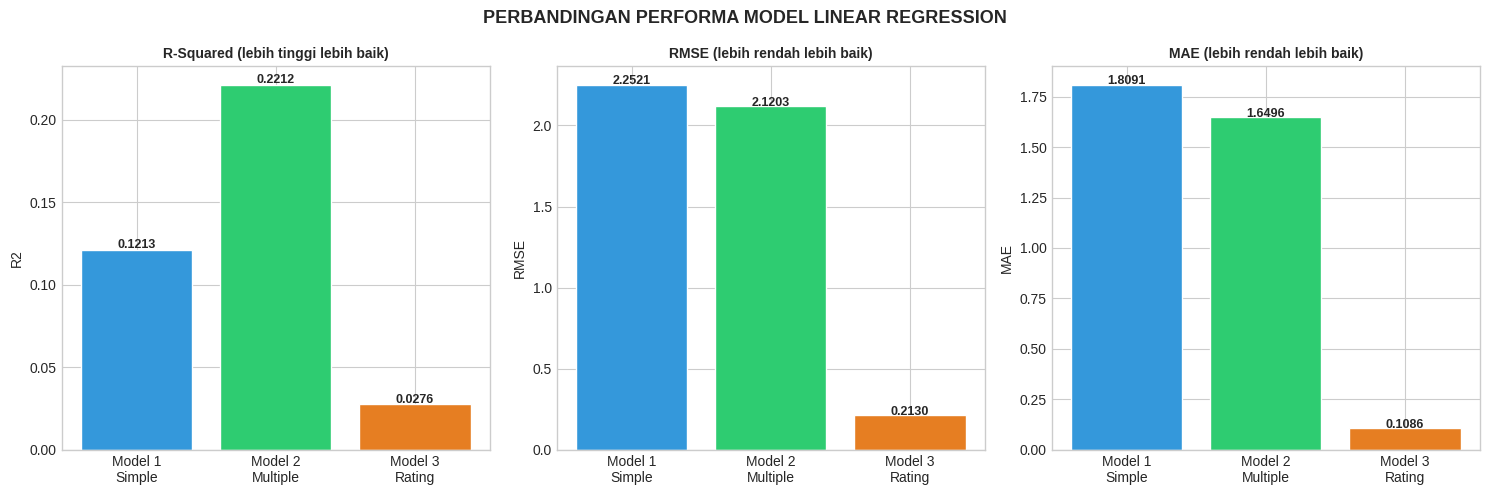


SIMULASI PREDIKSI — Masukkan Data Produk Baru

Produk                            Harga   Diskon   Pred.Terjual  Pred.Rating
---------------------------------------------------------------------------
Bumbu Marinasi Premium       Rp  45,000      10%           188 unit        4.88 bintang
Jilbab Instan Mid            Rp  95,000      15%           247 unit        4.88 bintang
Skincare Serum Vitamin C     Rp 180,000      20%           226 unit        4.89 bintang
Tas Selempang Casual         Rp 120,000       0%           121 unit        4.91 bintang
Suplemen Vitamin D3          Rp  75,000       5%           203 unit        4.89 bintang

* Prediksi Terjual = estimasi unit yang mungkin terjual berdasarkan karakteristik produk
* Prediksi Rating  = estimasi kepuasan konsumen berdasarkan fitur produk


In [ ]:
# ─── CELL 19: Perbandingan Semua Model & Simulasi Prediksi ──────────────────
print("="*65)
print("PERBANDINGAN PERFORMA 3 MODEL LINEAR REGRESSION")
print("="*65)

comparison = pd.DataFrame({
    'Model': [
        'Model 1: Simple (1 fitur)',
        'Model 2: Multiple (4 fitur)',
        'Model 3: Prediksi Rating'
    ],
    'Target': ['Log(Terjual)', 'Log(Terjual)', 'Rating'],
    'Fitur': ['Log(Harga)', 'Harga+Diskon+Rating+Ulasan', 'Harga+Diskon+Terjual+Ulasan'],
    'R2':   [round(r2_1,4), round(r2_2,4), round(r2_3,4)],
    'RMSE': [round(rmse1,4), round(rmse2,4), round(rmse3,4)],
    'MAE':  [round(mae1,4), round(mae2,4), round(mae3,4)]
})
print(comparison.to_string(index=False))
print("\nCatatan: R2 mendekati 1 = model lebih baik menjelaskan varians data")

# Bar chart perbandingan R2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('PERBANDINGAN PERFORMA MODEL LINEAR REGRESSION', fontsize=13, fontweight='bold')

model_labels = ['Model 1\nSimple', 'Model 2\nMultiple', 'Model 3\nRating']
colors_m = ['#3498db','#2ecc71','#e67e22']

for ax, metric, vals, title in zip(
    axes,
    ['R2', 'RMSE', 'MAE'],
    [[r2_1, r2_2, r2_3], [rmse1, rmse2, rmse3], [mae1, mae2, mae3]],
    ['R-Squared (lebih tinggi lebih baik)', 'RMSE (lebih rendah lebih baik)', 'MAE (lebih rendah lebih baik)']
):
    bars = ax.bar(model_labels, vals, color=colors_m, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(metric)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.001, f'{v:.4f}',
                ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('perbandingan_model.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Simulasi Prediksi Interaktif ─────────────────────────────────────────────
print("\n" + "="*65)
print("SIMULASI PREDIKSI — Masukkan Data Produk Baru")
print("="*65)

# Contoh prediksi untuk beberapa skenario produk
skenario = [
    {"nama": "Bumbu Marinasi Premium",  "harga": 45000,  "diskon": 10, "rating_input": 4.8, "ulasan": 50},
    {"nama": "Jilbab Instan Mid",       "harga": 95000,  "diskon": 15, "rating_input": 4.7, "ulasan": 200},
    {"nama": "Skincare Serum Vitamin C", "harga": 180000, "diskon": 20, "rating_input": 4.9, "ulasan": 500},
    {"nama": "Tas Selempang Casual",    "harga": 120000, "diskon": 0,  "rating_input": 4.5, "ulasan": 30},
    {"nama": "Suplemen Vitamin D3",     "harga": 75000,  "diskon": 5,  "rating_input": 4.6, "ulasan": 100},
]

print(f"\n{'Produk':<28} {'Harga':>10} {'Diskon':>8} {'Pred.Terjual':>14} {'Pred.Rating':>12}")
print("-"*75)
for s in skenario:
    log_h = np.log1p(s['harga'])
    log_u = np.log1p(s['ulasan'])

    # Prediksi terjual (Model 2)
    fitur_m2 = scaler2.transform([[log_h, s['diskon'], s['rating_input'], log_u]])
    pred_log_terjual = model2.predict(fitur_m2)[0]
    pred_terjual = int(np.expm1(pred_log_terjual))

    # Prediksi rating (Model 3)
    fitur_m3 = scaler3.transform([[log_h, s['diskon'], pred_log_terjual, log_u]])
    pred_rating = float(np.clip(model3.predict(fitur_m3)[0], 1, 5))

    print(f"{s['nama']:<28} Rp{s['harga']:>8,} {s['diskon']:>7}%  {pred_terjual:>12,} unit  {pred_rating:>10.2f} bintang")

print("\n* Prediksi Terjual = estimasi unit yang mungkin terjual berdasarkan karakteristik produk")
print("* Prediksi Rating  = estimasi kepuasan konsumen berdasarkan fitur produk")


In [ ]:
# ─── CELL 20: Kesimpulan & Interpretasi Linear Regression ───────────────────
print("="*65)
print("KESIMPULAN ANALISIS LINEAR REGRESSION")
print("="*65)

kesimpulan = [
    ("MODEL 1 — Simple Regression",
     f"Menggunakan 1 fitur (harga) untuk prediksi terjual. R2={r2_1:.3f}. "
     f"Semakin tinggi harga, cenderung terjual lebih sedikit (koefisien negatif: {model1.coef_[0]:.3f}). "
     f"R2 rendah karena 1 fitur tidak cukup menjelaskan perilaku penjualan."),
    ("MODEL 2 — Multiple Regression",
     f"Menggunakan 4 fitur (harga, diskon, rating, ulasan). R2={r2_2:.3f}. "
     f"Jumlah ulasan paling berpengaruh positif terhadap penjualan. "
     f"Harga berpengaruh negatif — produk lebih mahal cenderung lebih sulit terjual banyak."),
    ("MODEL 3 — Prediksi Rating",
     f"Memprediksi kepuasan konsumen. R2={r2_3:.3f}. "
     f"Diskon tinggi berkorelasi negatif dengan rating — konsumen lebih kritis pada produk diskonan. "
     f"MAE={mae3:.3f} artinya prediksi meleset sekitar {mae3:.2f} bintang."),
    ("REKOMENDASI BISNIS",
     "Berdasarkan regresi: fokus bangun ulasan dulu (paling pengaruh ke penjualan), "
     "jaga kualitas produk (hindari diskon terlalu besar agar rating tidak turun), "
     "dan pilih harga di segmen mid-low (50-200rb) untuk volume terjual optimal."),
]

for judul, isi in kesimpulan:
    print(f"\n[{judul}]")
    print(f"  {isi}")

print("\n" + "="*65)
print("SELESAI — Semua model tersimpan dan siap dipresentasikan.")
print("="*65)


KESIMPULAN ANALISIS LINEAR REGRESSION

[MODEL 1 — Simple Regression]
  Menggunakan 1 fitur (harga) untuk prediksi terjual. R2=0.121. Semakin tinggi harga, cenderung terjual lebih sedikit (koefisien negatif: -0.452). R2 rendah karena 1 fitur tidak cukup menjelaskan perilaku penjualan.

[MODEL 2 — Multiple Regression]
  Menggunakan 4 fitur (harga, diskon, rating, ulasan). R2=0.221. Jumlah ulasan paling berpengaruh positif terhadap penjualan. Harga berpengaruh negatif — produk lebih mahal cenderung lebih sulit terjual banyak.

[MODEL 3 — Prediksi Rating]
  Memprediksi kepuasan konsumen. R2=0.028. Diskon tinggi berkorelasi negatif dengan rating — konsumen lebih kritis pada produk diskonan. MAE=0.109 artinya prediksi meleset sekitar 0.11 bintang.

[REKOMENDASI BISNIS]
  Berdasarkan regresi: fokus bangun ulasan dulu (paling pengaruh ke penjualan), jaga kualitas produk (hindari diskon terlalu besar agar rating tidak turun), dan pilih harga di segmen mid-low (50-200rb) untuk volume terjual opt

In [ ]:
import pandas as pd
import numpy as np

# ==================================================
# DATASET MASTER TABLEAU
# ==================================================

df_tableau = df.copy()

# Add log-transformed features to df_tableau, similar to how df_model was prepared
# df already has 'Terjual_Num', 'Ulasan_Num' from previous cells
df_tableau['log_harga']   = np.log1p(df_tableau['Harga (IDR)'])
df_tableau['log_ulasan']  = np.log1p(df_tableau['Ulasan_Num'])

# Identify the rows that were used for model training based on df_model's criteria
# These are the rows for which 'model2' can make valid predictions.
# df_model filter: (df_reg['Terjual_Num'] > 0) & (df_reg['Harga (IDR)'] > 0) & (df_reg['Rating'] > 0)
# Replicate this filtering for df_tableau to get a consistent subset for prediction.
valid_for_prediction_mask = (df_tableau['Terjual_Num'] > 0) & \
                            (df_tableau['Harga (IDR)'] > 0) & \
                            (df_tableau['Rating'] > 0)

# Create a subset DataFrame from df_tableau for which we will generate predictions.
# This subset will have the same number of rows as X2 (25967 rows).
df_predict_subset = df_tableau[valid_for_prediction_mask].copy()

# Select the features required by model2 (as defined by 'features2' in cell e75126cb)
features2 = ['log_harga', 'Diskon (%)', 'Rating', 'log_ulasan']
X_predict_data_unscaled = df_predict_subset[features2]

# Scale these features using the 'scaler2' that was fitted during model2 training
X_predict_data_scaled = scaler2.transform(X_predict_data_unscaled)

# Make predictions using the trained model (model2 expects scaled data)
predicted_log_terjual_values = model2.predict(X_predict_data_scaled)

# Add the 'Predicted_Terjual_Log' column to the original df_tableau, initializing with NaN
df_tableau['Predicted_Terjual_Log'] = np.nan

# Assign the predicted values to the corresponding rows in df_tableau
# We use .loc and the index of df_predict_subset to ensure predictions align correctly
df_tableau.loc[valid_for_prediction_mask, 'Predicted_Terjual_Log'] = predicted_log_terjual_values

# Convert log-transformed predictions back to the original scale
df_tableau['Predicted_Terjual'] = np.exp(df_tableau['Predicted_Terjual_Log'])

# Drop the temporary log column if not needed for the final output
df_tableau.drop(columns=['Predicted_Terjual_Log'], inplace=True)


# Handle potential inf values resulting from np.exp(nan) or large numbers, if any
df_tableau['Predicted_Terjual'] = df_tableau['Predicted_Terjual'].replace([np.inf, -np.inf], np.nan)

df_tableau.to_csv(
    'tokopedia_tableau_dashboard.csv',
    index=False
)

print("tokopedia_tableau_dashboard.csv berhasil dibuat")
print(df_tableau.shape)

tokopedia_tableau_dashboard.csv berhasil dibuat
(29519, 19)
